# Data Loading

In [56]:
import pandas as pd
import numpy as np
import ast
import re

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

from collections import Counter
from itertools import combinations

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.decomposition import NMF, TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
import shap

from IPython.display import display

# ============================================================
# ANN IMPORTS
# ============================================================

import tensorflow as tf
tf.keras.utils.set_random_seed(42)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from scipy.sparse import hstack
from sklearn.preprocessing import StandardScaler

In [2]:
# Main international job postings dataset
jobs = pd.read_csv("data_jobs.csv")

# Philippine local dataset (reserved for later external validation)
lfs = pd.read_csv("FIES2015 - LFSJAN16 CSV - Cleaned.csv", low_memory=False)

# World Bank country-level context data
econ = pd.read_csv("world_bank_data_2025.csv")

print("jobs shape:", jobs.shape)
print("lfs shape:", lfs.shape)
print("econ shape:", econ.shape)

display(jobs.head())

jobs shape: (785741, 17)
lfs shape: (207212, 154)
econ shape: (3472, 16)


,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"['r', 'python', 'sql', 'nosql', 'power bi', 't...","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,NaN,NaN,NaN,ALPHA Augmented Services,"['python', 'sql', 'c#', 'azure', 'airflow', 'd...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,NaN,NaN,NaN,Kristina Daniel,"['bash', 'python', 'oracle', 'aws', 'ansible',...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."


# Data Preprocessing

In [3]:
# -------------------------
# COUNTRY STANDARDIZATION
# -------------------------
country_map = {
    "Russia": "Russian Federation",
    "Vietnam": "Viet Nam",
    "South Korea": "Korea, Rep.",
    "North Korea": "Korea, Dem. People's Rep.",
    "Egypt": "Egypt, Arab Rep.",
    "Côte d'Ivoire": "Cote d'Ivoire",
    "Iran": "Iran, Islamic Rep.",
    "Venezuela": "Venezuela, RB",
    "Slovakia": "Slovak Republic",
    "Hong Kong": "Hong Kong SAR, China",
    "Macedonia (FYROM)": "North Macedonia",
    "Palestine": "West Bank and Gaza",
    "Laos": "Lao PDR",
    "Syria": "Syrian Arab Republic",
    "Turkey": "Turkiye",
    "Yemen": "Yemen, Rep.",
    "United States Virgin Islands": "Virgin Islands (U.S.)",
    "Bahamas": "Bahamas, The",
    "Brunei": "Brunei Darussalam",
    "Congo, Democratic Republic of the": "Congo, Dem. Rep.",
    "Curaçao": "Curacao",
    "Gambia": "Gambia, The",
    "Kyrgyzstan": "Kyrgyz Republic",
    "Taiwan": "Taiwan, China",
    "U.S. Virgin Islands": "Virgin Islands (U.S.)"
}

In [4]:
# -------------------------
# WORLD BANK 2023 FEATURES
# -------------------------
econ_2023 = econ[econ["year"] == 2023].copy()

econ_2023 = econ_2023[[
    "country_name",
    "GDP per Capita (Current USD)",
    "GDP (Current USD)",
    "Unemployment Rate (%)",
    "Inflation (CPI %)",
    "GDP Growth (% Annual)"
]]

# interest rate, gross national income (USD)

econ_2023.columns = [
    "country",
    "gdp_per_capita",
    "gdp",
    "unemployment",
    "inflation",
    "gdp_growth"
]

display(econ_2023.head())

,country,gdp_per_capita,gdp,unemployment,inflation,gdp_growth
13,Aruba,33984.790620,3.648573e+09,NaN,NaN,4.263719
29,Afghanistan,415.707417,1.723305e+10,13.991,-4.644709,2.710887
45,Angola,2308.159767,8.482465e+10,14.537,13.644102,1.001289
61,Albania,8575.171134,2.354718e+10,10.108,4.759764,3.936625
77,Andorra,46812.448449,3.785067e+09,NaN,NaN,2.583555


In [5]:
# ============================================================
# LOAD COST OF LIVING DATA
# ============================================================
coli_df = pd.read_csv("cost-of-living_v2.csv")

# keep clean rows only
coli_df = coli_df[coli_df["data_quality"] == 1].copy()

# match your current filter (US + Canada)
coli_df = coli_df[coli_df["country"].isin(["United States", "Canada"])].copy()

# ============================================================
# BUILD COST-OF-LIVING INDICES
# ============================================================
coli_df["coli_housing"] = coli_df[["x48","x49","x50","x51","x52","x53"]].mean(axis=1)

coli_df["coli_groceries"] = coli_df[
    [f"x{i}" for i in range(9, 23)]
].mean(axis=1)

coli_df["coli_restaurant"] = coli_df[
    ["x1","x2","x3","x4","x5","x6","x7","x8","x41"]
].mean(axis=1)

coli_df["coli_transport"] = coli_df[
    ["x28","x29","x30","x31","x32","x33"]
].mean(axis=1)

coli_df["coli_utilities"] = coli_df[
    ["x36","x38"]
].mean(axis=1)

coli_df["coli_net_salary"] = coli_df["x54"]

# ============================================================
# FINAL COLUMN SET
# ============================================================
coli_cols = [
    "coli_housing",
    "coli_groceries",
    "coli_restaurant",
    "coli_transport",
    "coli_utilities",
    "coli_net_salary"
]

coli_cols_no_salary = [
    c for c in coli_cols if c != "coli_net_salary"
]

# lookup table
col_lookup = coli_df[["city","country"] + coli_cols].copy()
col_lookup["city_key"] = col_lookup["city"].str.lower().str.strip()

In [6]:
# -------------------------
# KEEP USEFUL COLUMNS
# -------------------------
wanted_cols = [
    "job_title_short",
    "job_title",
    "job_location",
    "job_via",
    "job_schedule_type",
    "job_work_from_home",
    "job_no_degree_mention",
    "job_health_insurance",
    "job_country",
    "salary_rate",
    "salary_year_avg",
    "salary_hour_avg",
    "company_name",
    "job_skills",
    "job_type_skills"
]

existing_cols = [c for c in wanted_cols if c in jobs.columns]

jobs_model = jobs[existing_cols].copy()

# standardize country names
jobs_model["job_country"] = jobs_model["job_country"].replace(country_map)

# # filter to North America
# jobs_model = jobs_model[jobs_model["job_country"].isin([
#     "United States", "Canada"
# ])].copy()

print("Shape after NA filter:", jobs_model.shape)

# merge economic features
jobs_model = jobs_model.merge(
    econ_2023,
    left_on="job_country",
    right_on="country",
    how="left"
)

# fill numeric macroeconomic missings with median
for col in ["gdp_per_capita", "gdp", "unemployment", "inflation", "gdp_growth"]:
    if col in jobs_model.columns:
        jobs_model[col] = jobs_model[col].fillna(jobs_model[col].median())

print("jobs_model shape after merge:", jobs_model.shape)
display(jobs_model.head())

Shape after NA filter: (785741, 15)
jobs_model shape after merge: (785741, 21)


,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,job_no_degree_mention,job_health_insurance,job_country,salary_rate,...,salary_hour_avg,company_name,job_skills,job_type_skills,country,gdp_per_capita,gdp,unemployment,inflation,gdp_growth
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,False,False,United States,NaN,...,NaN,Boehringer Ingelheim,NaN,NaN,United States,82769.412211,2.772071e+13,3.638,4.116338,2.887556
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,False,False,Mexico,NaN,...,NaN,Hewlett Packard Enterprise,"['r', 'python', 'sql', 'nosql', 'power bi', 't...","{'analyst_tools': ['power bi', 'tableau'], 'pr...",Mexico,13790.024343,1.789114e+12,2.765,5.527961,3.199981
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,False,False,Germany,NaN,...,NaN,ALPHA Augmented Services,"['python', 'sql', 'c#', 'azure', 'airflow', 'd...","{'analyst_tools': ['dax'], 'cloud': ['azure'],...",Germany,54343.226508,4.525704e+12,3.068,5.946437,-0.266438
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,True,False,United States,NaN,...,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',...",United States,82769.412211,2.772071e+13,3.638,4.116338,2.887556
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,False,False,Sudan,NaN,...,NaN,Kristina Daniel,"['bash', 'python', 'oracle', 'aws', 'ansible',...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl...",Sudan,2183.441406,1.092655e+11,3.668,4.311282,-20.111576


In [7]:
print(jobs_model["job_country"].value_counts())

job_country
United States     206292
India              51088
United Kingdom     40375
France             39922
Germany            27694
                   ...  
Guinea                 4
Lesotho                3
Mauritania             3
Bhutan                 3
Maldives               2
Name: count, Length: 160, dtype: int64


In [8]:
# -------------------------
# TARGET SALARY
# -------------------------
def get_salary(row):
    if pd.notna(row.get("salary_year_avg")):
        return row["salary_year_avg"]
    if pd.notna(row.get("salary_hour_avg")):
        return row["salary_hour_avg"] * 40 * 52
    return np.nan

jobs_model["salary"] = jobs_model.apply(get_salary, axis=1)
jobs_model = jobs_model.dropna(subset=["salary"]).copy()

print("Shape after removing missing salaries:", jobs_model.shape)

Shape after removing missing salaries: (32665, 22)


In [9]:
# remove salary outliers (IQR)
Q1 = jobs_model["salary"].quantile(0.25)
Q3 = jobs_model["salary"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

jobs_model = jobs_model[
    (jobs_model["salary"] >= lower) &
    (jobs_model["salary"] <= upper)
].copy()

jobs_model["salary_log"] = np.log1p(jobs_model["salary"])

print("Shape after outlier removal:", jobs_model.shape)
print("Salary summary:")
display(jobs_model["salary"].describe())

Shape after outlier removal: (32186, 23)
Salary summary:


count     32186.000000
mean     112195.970542
std       42660.262435
min       15000.000000
25%       80850.000000
50%      110000.000000
75%      142500.000000
max      241000.000000
Name: salary, dtype: float64

In [10]:
# -------------------------
# ADD ENGINEERED ECON FEATURES
# -------------------------
jobs_model["gdp_per_capita_log"] = np.log1p(jobs_model["gdp_per_capita"])
jobs_model["gdp_log"] = np.log1p(jobs_model["gdp"])
jobs_model["labor_market_tightness"] = 1 - jobs_model["unemployment"]
jobs_model["real_gdp_per_capita"] = jobs_model["gdp_per_capita"] / (1 + jobs_model["inflation"] / 100)

In [11]:
# -------------------------
# CLEAN SKILLS
# -------------------------
def clean_skills(x):
    if isinstance(x, list):
        all_items = []
        for item in x:
            text = str(item).strip().strip("'\"[]")
            parts = re.split(r",\s*", text)
            all_items.extend(parts)
        return [s.strip().strip("'\" ").lower() for s in all_items if s.strip()]
    
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return []
    
    if isinstance(x, str):
        try:
            parsed = ast.literal_eval(x)
            if isinstance(parsed, list):
                return clean_skills(parsed)
        except:
            pass
        x_clean = x.strip().strip("[]")
        parts = re.split(r",\s*", x_clean)
        return [s.strip().strip("'\" ").lower() for s in parts if s.strip()]
    
    return []

jobs_model["skills_list"] = jobs_model["job_skills"].apply(clean_skills)
jobs_model["skills_list"] = jobs_model["skills_list"].apply(lambda x: list(dict.fromkeys(x)))
jobs_model["skill_count"] = jobs_model["skills_list"].apply(len)

display(jobs_model[["job_skills", "skills_list", "skill_count"]].head(10))

,job_skills,skills_list,skill_count
28,"['gdpr', 'excel']","[gdpr, excel]",2
43,"['sql', 'sql server']","[sql, sql server]",2
51,"['python', 'java', 'aws', 'databricks', 'spark']","[python, java, aws, databricks, spark]",5
77,"['mongodb', 'mongodb', 'python', 'r', 'sql', '...","[mongodb, python, r, sql, mysql, mariadb, orac...",10
92,"['sql', 'python']","[sql, python]",2
100,"['sql', 'r', 'python', 'express']","[sql, r, python, express]",4
109,"['python', 'r', 'alteryx', 'tableau']","[python, r, alteryx, tableau]",4
116,"['r', 'python', 'sql', 't-sql', 'hadoop', 'spa...","[r, python, sql, t-sql, hadoop, spark, tableau]",7
146,"['golang', 'scala', 'python', 'java', 'hadoop'...","[golang, scala, python, java, hadoop, spark]",6
180,"['excel', 'powerpoint']","[excel, powerpoint]",2


In [12]:
# -------------------------
# PARSE job_type_skills
# -------------------------
def parse_skill_dict(x):
    if isinstance(x, dict):
        return x
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return {}
    if isinstance(x, str):
        try:
            parsed = ast.literal_eval(x)
            return parsed if isinstance(parsed, dict) else {}
        except:
            return {}
    return {}

jobs_model["job_type_skills_parsed"] = jobs_model["job_type_skills"].apply(parse_skill_dict)

skill_type_categories = [
    "analyst_tools", "cloud", "libraries", "databases", "programming",
    "other", "webframeworks", "os", "async", "sync"
]

for cat in skill_type_categories:
    jobs_model[f"{cat}_count"] = jobs_model["job_type_skills_parsed"].apply(
        lambda d: len(d.get(cat, [])) if isinstance(d, dict) else 0
    )

jobs_model["num_skill_categories"] = jobs_model["job_type_skills_parsed"].apply(
    lambda d: len([k for k, v in d.items() if isinstance(v, list) and len(v) > 0]) if isinstance(d, dict) else 0
)

display(
    jobs_model[
        ["job_type_skills", "job_type_skills_parsed"] +
        [f"{cat}_count" for cat in skill_type_categories] +
        ["num_skill_categories"]
    ].head(10)
)

,job_type_skills,job_type_skills_parsed,analyst_tools_count,cloud_count,libraries_count,databases_count,programming_count,other_count,webframeworks_count,os_count,async_count,sync_count,num_skill_categories
28,"{'analyst_tools': ['excel'], 'libraries': ['gd...","{'analyst_tools': ['excel'], 'libraries': ['gd...",1,0,1,0,0,0,0,0,0,0,2
43,"{'databases': ['sql server'], 'programming': [...","{'databases': ['sql server'], 'programming': [...",0,0,0,1,1,0,0,0,0,0,2
51,"{'cloud': ['aws', 'databricks'], 'libraries': ...","{'cloud': ['aws', 'databricks'], 'libraries': ...",0,2,1,0,2,0,0,0,0,0,3
77,"{'analyst_tools': ['tableau'], 'cloud': ['orac...","{'analyst_tools': ['tableau'], 'cloud': ['orac...",1,1,1,3,4,1,0,0,0,0,6
92,"{'programming': ['sql', 'python']}","{'programming': ['sql', 'python']}",0,0,0,0,2,0,0,0,0,0,1
100,"{'programming': ['sql', 'r', 'python'], 'webfr...","{'programming': ['sql', 'r', 'python'], 'webfr...",0,0,0,0,3,0,1,0,0,0,2
109,"{'analyst_tools': ['alteryx', 'tableau'], 'pro...","{'analyst_tools': ['alteryx', 'tableau'], 'pro...",2,0,0,0,2,0,0,0,0,0,2
116,"{'analyst_tools': ['tableau'], 'libraries': ['...","{'analyst_tools': ['tableau'], 'libraries': ['...",1,0,2,0,4,0,0,0,0,0,3
146,"{'libraries': ['hadoop', 'spark'], 'programmin...","{'libraries': ['hadoop', 'spark'], 'programmin...",0,0,2,0,4,0,0,0,0,0,2
180,"{'analyst_tools': ['excel', 'powerpoint']}","{'analyst_tools': ['excel', 'powerpoint']}",2,0,0,0,0,0,0,0,0,0,1


In [13]:
# -------------------------
# REGION GROUPING
# -------------------------
region_map = {
    "United States": "NA", "Canada": "NA",
    "Mexico": "LATAM", "Costa Rica": "LATAM", "Guatemala": "LATAM", "Panama": "LATAM",
    "Brazil": "LATAM", "Argentina": "LATAM", "Chile": "LATAM", "Peru": "LATAM",
    "United Kingdom": "EU", "Germany": "EU", "France": "EU", "Spain": "EU", "Italy": "EU",
    "Belgium": "EU", "Denmark": "EU", "Poland": "EU", "Portugal": "EU", "Sweden": "EU",
    "Netherlands": "EU", "Ireland": "EU", "Austria": "EU", "Romania": "EU", "Finland": "EU",
    "Switzerland": "EU", "Norway": "EU",
    "Philippines": "SEA", "Singapore": "SEA", "Indonesia": "SEA", "Malaysia": "SEA",
    "Thailand": "SEA", "Viet Nam": "SEA", "Brunei Darussalam": "SEA",
    "Japan": "EAST_ASIA", "Korea, Rep.": "EAST_ASIA", "Taiwan, China": "EAST_ASIA", "China": "EAST_ASIA",
    "India": "SOUTH_ASIA", "Pakistan": "SOUTH_ASIA", "Bangladesh": "SOUTH_ASIA",
    "United Arab Emirates": "ME", "Israel": "ME", "Jordan": "ME", "Turkiye": "ME",
    "South Africa": "AFRICA", "Nigeria": "AFRICA", "Kenya": "AFRICA", "Morocco": "AFRICA", "Egypt, Arab Rep.": "AFRICA",
    "Australia": "OCEANIA", "New Zealand": "OCEANIA"
}

jobs_model["region"] = jobs_model["job_country"].map(region_map).fillna("OTHER")

In [14]:
# -------------------------
# FILTER RARE TITLES
# -------------------------
title_counts = jobs_model["job_title_short"].value_counts()
common_titles = title_counts[title_counts >= 100].index

jobs_model = jobs_model[jobs_model["job_title_short"].isin(common_titles)].copy()

print("Final modeling dataframe shape:", jobs_model.shape)
display(jobs_model.head())

Final modeling dataframe shape: (32101, 42)


,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,job_no_degree_mention,job_health_insurance,job_country,salary_rate,...,libraries_count,databases_count,programming_count,other_count,webframeworks_count,os_count,async_count,sync_count,num_skill_categories,region
28,Data Scientist,CRM Data Specialist,"San José Province, San José, Costa Rica",via Ai-Jobs.net,Full-time,False,False,False,Costa Rica,year,...,1,0,0,0,0,0,0,0,2,LATAM
43,Senior Data Engineer,Sr SQL Database Engineer with Data Warehouse /...,NaN,via LinkedIn,Contractor,False,True,False,United States,hour,...,0,1,1,0,0,0,0,0,2,NA
51,Senior Data Engineer,Senior Data Engineer,Anywhere,via LinkedIn,Contractor,True,False,False,United States,hour,...,1,0,2,0,0,0,0,0,3,NA
77,Data Engineer,Data Engineer,"Arlington, VA",via LinkedIn,Full-time,False,False,False,Sudan,year,...,1,3,4,1,0,0,0,0,6,OTHER
92,Data Engineer,Remote - Data Engineer - Permanent - W2,Anywhere,via LinkedIn,Full-time,True,False,True,United States,year,...,0,0,2,0,0,0,0,0,1,NA


In [15]:
jobs_model = jobs_model.drop(columns=["job_skills"])

# Add Feature Engineering after EDA

In [16]:
# -------------------------
# ADD COUNTRY GROUPING
# -------------------------
top_countries_global = jobs_model["job_country"].value_counts().head(20).index.tolist()

jobs_model["country_grouped"] = jobs_model["job_country"].where(
    jobs_model["job_country"].isin(top_countries_global),
    "OTHER"
)

# -------------------------
# TITLE FEATURES
# -------------------------
jobs_model["job_title_clean"] = jobs_model["job_title"].fillna("").astype(str).str.lower()

jobs_model["is_senior"] = jobs_model["job_title_clean"].str.contains(r"\bsenior\b", regex=True).astype(int)
jobs_model["is_lead"] = jobs_model["job_title_clean"].str.contains(r"\blead\b", regex=True).astype(int)
jobs_model["is_principal"] = jobs_model["job_title_clean"].str.contains(r"\bprincipal\b", regex=True).astype(int)
jobs_model["is_manager"] = jobs_model["job_title_clean"].str.contains(r"\bmanager\b", regex=True).astype(int)
jobs_model["is_junior"] = jobs_model["job_title_clean"].str.contains(r"\bjunior\b", regex=True).astype(int)
jobs_model["is_intern"] = jobs_model["job_title_clean"].str.contains(r"\bintern\b", regex=True).astype(int)

jobs_model["title_length"] = jobs_model["job_title"].fillna("").astype(str).apply(len)
jobs_model["title_word_count"] = jobs_model["job_title"].fillna("").astype(str).apply(lambda x: len(x.split()))

# -------------------------
# STACK FEATURES FROM skills_list
# -------------------------
jobs_model["cloud_stack"] = jobs_model["skills_list"].apply(
    lambda x: sum(skill in x for skill in ["aws", "azure", "gcp", "databricks"])
)

jobs_model["visualization_stack"] = jobs_model["skills_list"].apply(
    lambda x: sum(skill in x for skill in ["tableau", "power bi", "looker", "qlik"])
)

jobs_model["ml_stack"] = jobs_model["skills_list"].apply(
    lambda x: sum(skill in x for skill in ["tensorflow", "pytorch", "scikit-learn", "keras"])
)

jobs_model["big_data_stack"] = jobs_model["skills_list"].apply(
    lambda x: sum(skill in x for skill in ["spark", "hadoop", "kafka", "airflow"])
)

jobs_model["core_data_stack"] = jobs_model["skills_list"].apply(
    lambda x: sum(skill in x for skill in ["sql", "python", "r", "excel"])
)

# -------------------------
# FEATURE INTERACTIONS
# -------------------------

jobs_model["senior_x_ml"] = jobs_model["is_senior"] * jobs_model["ml_stack"]
jobs_model["cloud_x_gdp"] = jobs_model["cloud_stack"] * jobs_model["gdp_per_capita_log"]
jobs_model["data_stack_total"] = (
    jobs_model["cloud_stack"] +
    jobs_model["ml_stack"] +
    jobs_model["big_data_stack"]
)

print("Shape after additional feature engineering:", jobs_model.shape)
display(jobs_model.head())

Shape after additional feature engineering: (32101, 59)


,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,job_no_degree_mention,job_health_insurance,job_country,salary_rate,...,title_length,title_word_count,cloud_stack,visualization_stack,ml_stack,big_data_stack,core_data_stack,senior_x_ml,cloud_x_gdp,data_stack_total
28,Data Scientist,CRM Data Specialist,"San José Province, San José, Costa Rica",via Ai-Jobs.net,Full-time,False,False,False,Costa Rica,year,...,19,3,0,0,0,0,1,0,0.000000,0
43,Senior Data Engineer,Sr SQL Database Engineer with Data Warehouse /...,NaN,via LinkedIn,Contractor,False,True,False,United States,hour,...,60,10,0,0,0,0,1,0,0.000000,0
51,Senior Data Engineer,Senior Data Engineer,Anywhere,via LinkedIn,Contractor,True,False,False,United States,hour,...,20,3,2,0,0,1,1,0,22.647652,3
77,Data Engineer,Data Engineer,"Arlington, VA",via LinkedIn,Full-time,False,False,False,Sudan,year,...,13,2,0,1,0,1,3,0,0.000000,1
92,Data Engineer,Remote - Data Engineer - Permanent - W2,Anywhere,via LinkedIn,Full-time,True,False,True,United States,year,...,39,8,0,0,0,0,2,0,0.000000,0


# More Cleaning

In [17]:
df = jobs_model.copy()

In [18]:
# ============================================================
# EXTRACT CITY FROM job_location
# ============================================================
def extract_city(loc):
    if pd.isna(loc):
        return None
    
    loc = str(loc).lower().strip()
    
    bad_values = ["anywhere", "united states", "canada", "remote"]
    if loc in bad_values:
        return None
    
    parts = loc.split(",")
    city = parts[0].strip() if parts else None
    
    if city:
        city = city.replace(".", "")
    
    return city

df["city_key"] = df["job_location"].apply(extract_city)

In [19]:
city_fix_map = {
    "new york": "new york city",
    "washington": "washington dc",
    "st louis": "st louis",
}
df["city_key"] = df["city_key"].replace(city_fix_map)

In [20]:
# ============================================================
# MERGE COST-OF-LIVING DATA
# ============================================================
col_lookup["_merge_flag"] = 1

df = df.merge(
    col_lookup.drop(columns=["city","country"]),
    on="city_key",
    how="left"
)

df["coli_matched"] = df["_merge_flag"].fillna(0).astype(int)
df = df.drop(columns=["_merge_flag"])

# check match rate
match_rate = df["coli_matched"].mean()
print(f"COLI match rate: {match_rate:.2%}")

# fill missing with median (IMPORTANT)
for c in coli_cols:
    df[c] = df[c].fillna(df[c].median())

COLI match rate: 28.14%


In [21]:
print(df["city_key"].value_counts().head(20))

city_key
new york city    1338
atlanta           626
san francisco     614
washington dc     562
austin            552
chicago           491
charlotte         453
dallas            437
los angeles       421
tampa             328
boston            315
san jose          267
arlington         256
irving            254
bengaluru         232
mountain view     208
houston           201
miami             191
st louis          175
toronto           170
Name: count, dtype: int64


In [22]:
# ======================================================
# TITLE CLEANING
# ======================================================

df["job_title_clean"] = df["job_title"].fillna("").str.lower()

In [23]:
# ======================================================
# GRANULAR SENIORITY FEATURES
# ======================================================

df["is_junior"]     = df["job_title_clean"].str.contains(r"\bjunior\b|\bjr\b").astype(int)
df["is_mid"]        = df["job_title_clean"].str.contains(r"\bassociate\b").astype(int)
df["is_senior"]     = df["job_title_clean"].str.contains(r"\bsenior\b|\bsr\b").astype(int)
df["is_lead"]       = df["job_title_clean"].str.contains(r"\blead\b").astype(int)
df["is_manager"]    = df["job_title_clean"].str.contains(r"\bmanager\b").astype(int)
df["is_director"]   = df["job_title_clean"].str.contains(r"\bdirector\b").astype(int)
df["is_principal"]  = df["job_title_clean"].str.contains(r"\bprincipal\b").astype(int)
df["is_staff"]      = df["job_title_clean"].str.contains(r"\bstaff\b").astype(int)
df["is_head"]       = df["job_title_clean"].str.contains(r"\bhead\b").astype(int)

In [24]:
# ======================================================
# LOCATION PREMIUM FEATURES
# ======================================================

df["job_location_clean"] = df["job_location"].fillna("").str.lower()

premium_cities = [
    "san francisco",
    "san jose",
    "new york",
    "seattle",
    "boston",
    "austin",
    "los angeles",
    "chicago"]

for city in premium_cities:
    col_name = "loc_" + city.replace(" ", "_")
    df[col_name] = df["job_location_clean"].str.contains(city).astype(int)

city_cols = [c for c in df.columns if c.startswith("loc_")]

df["is_major_city"] = (df[city_cols].sum(axis=1) > 0).astype(int)

In [25]:
# ======================================================
# CONTRACT / SALARY TYPE FEATURES
# ======================================================

df["is_hourly"] = (df["salary_rate"] == "hour").astype(int)
df["is_yearly"] = (df["salary_rate"] == "year").astype(int)
df["is_contract"] = df["job_schedule_type"].fillna("").str.lower().str.contains("contract").astype(int)
df["is_fulltime"] = df["job_schedule_type"].fillna("").str.lower().str.contains("full").astype(int)

df["via_upwork"] = df["job_via"].fillna("").str.lower().str.contains("upwork").astype(int)
df["via_linkedin"] = df["job_via"].fillna("").str.lower().str.contains("linkedin").astype(int)
df["via_indeed"] = df["job_via"].fillna("").str.lower().str.contains("indeed").astype(int)

In [26]:
# ======================================================
# HIGH VALUE TITLE KEYWORDS 
# justification
# ======================================================

df["contains_architect"] = df["job_title_clean"].str.contains("architect").astype(int)
df["contains_startup"]   = df["job_title_clean"].str.contains("startup").astype(int)
df["contains_growth"]    = df["job_title_clean"].str.contains("growth").astype(int)
df["contains_research"]  = df["job_title_clean"].str.contains("research").astype(int)
df["contains_ml"]        = df["job_title_clean"].str.contains("machine learning|ml").astype(int)

In [27]:
# ======================================================
# INTERACTION FEATURES
# ======================================================

df["seniority_score"] = (
    df["is_senior"] +
    df["is_lead"] * 2 +
    df["is_manager"] * 2 +
    df["is_director"] * 3 +
    df["is_principal"] * 3 +
    df["is_staff"] * 3 +
    df["is_head"] * 4
)

In [28]:
df["premium_city_x_senior"] = df["is_major_city"] * df["seniority_score"]

df["skill_x_senior"] = df["skill_count"] * df["seniority_score"]

df["cloud_x_bigdata"] = df["cloud_stack"] * df["big_data_stack"]

In [29]:
# ======================================================
# [OPTIONAL] TARGET CLEANING
# Winsorize extreme salaries
# ======================================================

lower = df["salary"].quantile(0.01)
upper = df["salary"].quantile(0.99)

df["salary_clean"] = df["salary"].clip(lower, upper)
df["salary_log_clean"] = np.log1p(df["salary_clean"])

In [30]:
print("Feature engineering complete.")
print("New shape:", df.shape)

Feature engineering complete.
New shape: (32166, 99)


In [31]:
print("Final number of samples after preprocessing and filtering:", len(df))

Final number of samples after preprocessing and filtering: 32166


In [32]:
df.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,job_no_degree_mention,job_health_insurance,job_country,salary_rate,...,contains_startup,contains_growth,contains_research,contains_ml,seniority_score,premium_city_x_senior,skill_x_senior,cloud_x_bigdata,salary_clean,salary_log_clean
0,Data Scientist,CRM Data Specialist,"San José Province, San José, Costa Rica",via Ai-Jobs.net,Full-time,False,False,False,Costa Rica,year,...,0,0,0,0,0,0,0,0,109500.0,11.603689
1,Senior Data Engineer,Sr SQL Database Engineer with Data Warehouse /...,NaN,via LinkedIn,Contractor,False,True,False,United States,hour,...,0,0,0,0,1,0,2,0,202800.0,12.219980
2,Senior Data Engineer,Senior Data Engineer,Anywhere,via LinkedIn,Contractor,True,False,False,United States,hour,...,0,0,0,0,1,0,5,2,150800.0,11.923716
3,Data Engineer,Data Engineer,"Arlington, VA",via LinkedIn,Full-time,False,False,False,Sudan,year,...,0,0,0,0,0,0,0,0,140000.0,11.849405
4,Data Engineer,Remote - Data Engineer - Permanent - W2,Anywhere,via LinkedIn,Full-time,True,False,True,United States,year,...,0,0,0,0,0,0,0,0,120000.0,11.695255


In [33]:
econ_cols = [
    "gdp_per_capita",
    "gdp",
    "unemployment",
    "inflation",
    "gdp_growth",
    "gdp_per_capita_log",
    "gdp_log",
    "labor_market_tightness",
    "real_gdp_per_capita"]

available_econ_cols = [c for c in econ_cols if c in df.columns]

In [34]:
# ============================================================
# BASE FEATURE SET (WITHOUT ECONOMIC FEATURES)
# ============================================================

base_features = [
    "skill_count",
    "cloud_stack",
    "ml_stack",
    "big_data_stack",
    "seniority_score",
    "is_major_city",
    "is_hourly",
    "is_yearly",
    "is_contract",
    "is_fulltime",
    "via_upwork",
    "via_linkedin",
    "via_indeed",
    "contains_architect",
    "contains_growth",
    "contains_research",
    "contains_ml",
    "premium_city_x_senior",
    "skill_x_senior",
    "cloud_x_bigdata"
] + city_cols

# Keep only existing columns
base_features = [c for c in base_features if c in df.columns]

# Helper Functions

In [35]:
def regression_metrics(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred))
    }

def xgb_safe_df(df):
    df = df.copy()
    df.columns = [
        str(c).replace("[", "_")
              .replace("]", "_")
              .replace("<", "_")
              .replace(">", "_")
              .replace(" ", "_")
        for c in df.columns
    ]
    return df

In [36]:
# ============================================================
# FUNCTION TO TRAIN MODEL
# ============================================================

def run_xgb_model(feature_list, label="Model"):

    X = df[feature_list].copy()
    y = df["salary_log_clean"].copy()

    X = xgb_safe_df(X)

    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=0.15, random_state=42
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.1765, random_state=42
    )

    model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=5,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=2,
        gamma=0.1,
        random_state=42,
        n_jobs=2,
        tree_method="hist"
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    print(model.get_booster().attributes())

    pred_log = model.predict(X_test)

    pred = np.expm1(pred_log)
    actual = np.expm1(y_test)

    metrics = regression_metrics(actual, pred)

    result = pd.DataFrame([{
        "Model": label,
        "Features": len(feature_list),
        "R2": metrics["R2"],
        "MAE": metrics["MAE"],
        "RMSE": metrics["RMSE"]
    }])

    importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": model.feature_importances_
    }).sort_values("Importance", ascending=False)

    return result, model, importance

# Naive Baseline Model

In [37]:
# ============================================================
# NAIVE BASELINE HELPERS
# ============================================================

from sklearn.dummy import DummyRegressor

def evaluate_naive_baseline(dataframe, label="Naive Baseline"):

    # --------------------------------------------------------
    # TARGET
    # --------------------------------------------------------
    y = dataframe["salary_clean"].copy()

    # dummy feature (required by sklearn)
    X = pd.DataFrame({"dummy": np.zeros(len(dataframe))})

    # --------------------------------------------------------
    # TRAIN / TEST SPLIT
    # SAME RANDOM STATE FOR FAIRNESS
    # --------------------------------------------------------
    X_temp, X_test, y_temp, y_test = train_test_split(
        X,
        y,
        test_size=0.15,
        random_state=42
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_temp,
        y_temp,
        test_size=0.1765,
        random_state=42
    )

    # --------------------------------------------------------
    # DUMMY MODEL
    # predicts mean salary
    # --------------------------------------------------------
    model = DummyRegressor(strategy="mean")

    model.fit(X_train, y_train)

    # --------------------------------------------------------
    # PREDICTIONS
    # --------------------------------------------------------
    pred_train = model.predict(X_train)
    pred_val   = model.predict(X_val)
    pred_test  = model.predict(X_test)

    actual_train = y_train
    actual_val   = y_val
    actual_test  = y_test

    # --------------------------------------------------------
    # METRICS
    # --------------------------------------------------------
    train_metrics = regression_metrics(actual_train, pred_train)
    val_metrics   = regression_metrics(actual_val, pred_val)
    test_metrics  = regression_metrics(actual_test, pred_test)

    # --------------------------------------------------------
    # RESULTS TABLE
    # --------------------------------------------------------
    results = pd.DataFrame([
    {
        "Model": label,
        "Dataset": "Train",
        "R2": train_metrics["R2"],
        "MAE": train_metrics["MAE"],
        "RMSE": train_metrics["RMSE"]
    },
    {
        "Model": label,
        "Dataset": "Validation",
        "R2": val_metrics["R2"],
        "MAE": val_metrics["MAE"],
        "RMSE": val_metrics["RMSE"]
    },
    {
        "Model": label,
        "Dataset": "Test",
        "R2": test_metrics["R2"],
        "MAE": test_metrics["MAE"],
        "RMSE": test_metrics["RMSE"]
    }
    ])

    return results

In [38]:
# ============================================================
# BUILD DATASETS
# ============================================================

# ALL COUNTRIES
df_all = df.copy()

# NORTH AMERICA ONLY
df_na = df[
    df["job_country"].isin(["United States", "Canada"])
].copy()

print("All Countries Shape:", df_all.shape)
print("NA Shape:", df_na.shape)

All Countries Shape: (32166, 99)
NA Shape: (25295, 99)


In [39]:
# ============================================================
# RUN NAIVE BASELINES
# ============================================================

results_naive_all = evaluate_naive_baseline(
    df_all,
    label="Naive Baseline (All Countries)"
)

results_naive_na = evaluate_naive_baseline(
    df_na,
    label="Naive Baseline (North America)"
)

naive_results = pd.concat([
    results_naive_all,
    results_naive_na
], axis=0)

# formatting
naive_results["R2"] = (naive_results["R2"] * 100).round(2)
naive_results["MAE"] = naive_results["MAE"].round(2)
naive_results["RMSE"] = naive_results["RMSE"].round(2)

display(naive_results)

,Model,Dataset,R2,MAE,RMSE
0,Naive Baseline (All Countries),Train,0.00,34429.35,42187.95
1,Naive Baseline (All Countries),Validation,-0.01,34505.31,42202.50
2,Naive Baseline (All Countries),Test,-0.01,35101.28,43029.65
0,Naive Baseline (North America),Train,0.00,34124.75,42265.66
1,Naive Baseline (North America),Validation,-0.00,34557.14,42426.57
2,Naive Baseline (North America),Test,-0.00,34676.82,42692.93


In [40]:
# ============================================================
# RESTRICT MAIN MODELING PIPELINE TO NORTH AMERICA
# ============================================================

df = df[
    df["job_country"].isin([
        "United States",
        "Canada"
    ])
].copy()

print("NA-only modeling shape:", df.shape)
print(df["job_country"].value_counts())

NA-only modeling shape: (25295, 99)
job_country
United States    24793
Canada             502
Name: count, dtype: int64


# Models A & B (With or Without Economic Features)

In [41]:
# ============================================================
# DEFINE FEATURE SETS FIRST
# ============================================================

def dedup(seq):
    seen = set()
    return [x for x in seq if not (x in seen or seen.add(x))]

features_macro = dedup(base_features + available_econ_cols)
features_micro = dedup(base_features + coli_cols + ["coli_matched"])
features_macro_micro = dedup(base_features + available_econ_cols + coli_cols + ["coli_matched"])
features_micro_no_salary = dedup(base_features + coli_cols_no_salary + ["coli_matched"])
features_macro_micro_no_salary = dedup(base_features + available_econ_cols + coli_cols_no_salary + ["coli_matched"])

# ============================================================
# RUN MODELS
# ============================================================

results_base, _, _ = run_xgb_model(
    base_features,
    label="XGBoost (No Economic Features)"
)

results_macro, model_macro, imp_macro = run_xgb_model(
    features_macro,
    label="XGBoost with Macroeconomic Features"
)

results_micro, _, _ = run_xgb_model(
    features_micro,
    label="XGBoost with Cost-of-Living Features"
)

results_macro_micro, _, _ = run_xgb_model(
    features_macro_micro,
    label="XGBoost with Macroeconomic + Cost-of-Living Features"
)

results_micro_no_salary, _, _ = run_xgb_model(
    features_micro_no_salary,
    label="XGBoost with Cost-of-Living Features (No Salary)"
)

{}
{}
{}
{}
{}


# Compare Results

In [42]:
display(imp_macro.head(25))

,Feature,Importance
4,seniority_score,0.194917
7,is_yearly,0.118683
8,is_contract,0.114356
6,is_hourly,0.097281
1,cloud_stack,0.044788
3,big_data_stack,0.043749
11,via_linkedin,0.041470
10,via_upwork,0.038338
18,skill_x_senior,0.032198
20,loc_san_francisco,0.029409


In [43]:
econ_importance = imp_macro[
    imp_macro["Feature"].isin(
        [c.replace(" ", "_") for c in available_econ_cols]
    )
]

display(econ_importance)

,Feature,Importance
28,gdp_per_capita,0.007951
29,gdp,0.006431
30,unemployment,0.004019
31,inflation,0.000000
32,gdp_growth,0.000000
33,gdp_per_capita_log,0.000000
34,gdp_log,0.000000
35,labor_market_tightness,0.000000
36,real_gdp_per_capita,0.000000


# With SBERT and TFIDF

In [44]:
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from scipy.sparse import hstack, csr_matrix

In [45]:
# ============================================================
# PREP TEXT DATA
# ============================================================

df["job_title_text"] = df["job_title"].fillna("").astype(str)
df["skills_text"] = df["skills_list"].apply(
    lambda x: " ".join(x) if isinstance(x, list) else ""
)

In [46]:
# ============================================================
# TRAIN / TEST SPLIT USING SAME RANDOM STATE
# ============================================================

train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.15,
    random_state=42
)

trainval_idx, val_idx = train_test_split(
    train_idx,
    test_size=0.1765,
    random_state=42
)

In [47]:
# ============================================================
# SBERT MODEL
# ============================================================

sbert = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1430.32it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [48]:
def run_xgb_hybrid(feature_list, label="Hybrid Model"):

    # -----------------------------
    # Structured Features
    # -----------------------------
    X_struct = df[feature_list].copy()
    X_struct = xgb_safe_df(X_struct)

    y = df["salary_log_clean"].copy()

    X_train = X_struct.loc[trainval_idx]
    X_val   = X_struct.loc[val_idx]
    X_test  = X_struct.loc[test_idx]

    y_train = y.loc[trainval_idx]
    y_val   = y.loc[val_idx]
    y_test  = y.loc[test_idx]

    # -----------------------------
    # SBERT Title Embeddings
    # -----------------------------
    title_train = df.loc[trainval_idx, "job_title_text"].tolist()
    title_val   = df.loc[val_idx, "job_title_text"].tolist()
    title_test  = df.loc[test_idx, "job_title_text"].tolist()

    emb_train = csr_matrix(sbert.encode(title_train, batch_size=64, show_progress_bar=True))
    emb_val   = csr_matrix(sbert.encode(title_val, batch_size=64, show_progress_bar=True))
    emb_test  = csr_matrix(sbert.encode(title_test, batch_size=64, show_progress_bar=True))

    # -----------------------------
    # TF-IDF Skills
    # -----------------------------
    tfidf = TfidfVectorizer(
        max_features=4000,
        ngram_range=(1,2),
        min_df=3,
        max_df=0.90,
        stop_words="english"
    )

    tf_train = tfidf.fit_transform(df.loc[trainval_idx, "skills_text"])
    tf_val   = tfidf.transform(df.loc[val_idx, "skills_text"])
    tf_test  = tfidf.transform(df.loc[test_idx, "skills_text"])

    # -----------------------------
    # Final Hybrid Matrices
    # -----------------------------
    X_train_F = hstack([csr_matrix(X_train.values), emb_train, tf_train]).tocsr()
    X_val_F   = hstack([csr_matrix(X_val.values), emb_val, tf_val]).tocsr()
    X_test_F  = hstack([csr_matrix(X_test.values), emb_test, tf_test]).tocsr()

    # -----------------------------
    # Model
    # -----------------------------
    model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=5,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=2,
        gamma=0.1,
        random_state=42,
        n_jobs=2,
        tree_method="hist"
    )

    model.fit(
        X_train_F,
        y_train,
        eval_set=[(X_val_F, y_val)],
        verbose=False
    )

    # -----------------------------
    # Predictions
    # -----------------------------
    def inverse_predict(X, y_true):
        pred_log = model.predict(X)
        pred = np.expm1(pred_log)
        actual = np.expm1(y_true)
        return regression_metrics(actual, pred)

    train_metrics = inverse_predict(X_train_F, y_train)
    val_metrics   = inverse_predict(X_val_F, y_val)
    test_metrics  = inverse_predict(X_test_F, y_test)

    # -----------------------------
    # Results Table
    # -----------------------------
    result = pd.DataFrame([
        {
            "Model": label + " (Train)",
            "R2": train_metrics["R2"],
            "MAE": train_metrics["MAE"],
            "RMSE": train_metrics["RMSE"]
        },
        {
            "Model": label + " (Validation)",
            "R2": val_metrics["R2"],
            "MAE": val_metrics["MAE"],
            "RMSE": val_metrics["RMSE"]
        },
        {
            "Model": label + " (Test)",
            "R2": test_metrics["R2"],
            "MAE": test_metrics["MAE"],
            "RMSE": test_metrics["RMSE"]
        }
    ])

    return result

In [49]:
# ============================================================
# RUN HYBRID MODELS
# ============================================================

results_hybrid_base = run_xgb_hybrid(
    base_features,
    label="XGBoost + SBERT + TF-IDF (No Econ)"
)

results_hybrid_macro = run_xgb_hybrid(
    features_macro,
    label="XGBoost + SBERT + TF-IDF + Macro"
)

results_hybrid_micro = run_xgb_hybrid(
    features_micro,
    label="XGBoost + SBERT + TF-IDF + Micro"
)

results_hybrid_macro_micro = run_xgb_hybrid(
    features_macro_micro,
    label="XGBoost + SBERT + TF-IDF + Macro + Micro"
)

results_hybrid_micro_no_salary = run_xgb_hybrid(
    features_micro_no_salary,
    label="XGBoost + SBERT + TF-IDF + Micro (No Salary)"
)

results_hybrid_macro_micro_no_salary = run_xgb_hybrid(
    features_macro_micro_no_salary,
    label="XGBoost + SBERT + TF-IDF + Macro + Micro (No Salary)"
)

Batches: 100%|██████████| 60/60 [00:00<00:00, 70.87it/s]


In [50]:
comparison = pd.concat([
    results_hybrid_base,
    results_hybrid_macro,
    results_hybrid_micro,
    results_hybrid_micro_no_salary,
    results_hybrid_macro_micro,
    results_hybrid_macro_micro_no_salary
], axis=0)

In [51]:
# ============================================================
# COMPARE ALL MODELS
# ============================================================

model_results = comparison.copy()

# Extract dataset into separate column
model_results["Dataset"] = model_results["Model"].str.extract(
    r"\((Train|Validation|Test)\)"
)

# Remove dataset labels from model names
model_results["Model"] = model_results["Model"].str.replace(
    r" \((Train|Validation|Test)\)",
    "",
    regex=True
)

# Optional formatting
model_results["R2"] = (model_results["R2"] * 100).round(2)
model_results["MAE"] = model_results["MAE"].round(2)
model_results["RMSE"] = model_results["RMSE"].round(2)

final_table = model_results[
    ["Model", "Dataset", "R2", "MAE", "RMSE"]
].sort_values(
    ["Dataset", "R2"],
    ascending=[True, False]
).reset_index(drop=True)

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

display(final_table)

,Model,Dataset,R2,MAE,RMSE
0,XGBoost + SBERT + TF-IDF + Macro + Micro,Test,53.81,22006.53,29016.03
1,XGBoost + SBERT + TF-IDF + Micro,Test,53.73,22019.54,29039.29
2,XGBoost + SBERT + TF-IDF + Micro (No Salary),Test,53.46,22056.03,29125.32
3,XGBoost + SBERT + TF-IDF + Macro + Micro (No Salary),Test,53.40,22106.55,29143.00
4,XGBoost + SBERT + TF-IDF (No Econ),Test,53.03,22261.17,29259.24
5,XGBoost + SBERT + TF-IDF + Macro,Test,52.78,22286.48,29338.29
6,XGBoost + SBERT + TF-IDF + Micro,Train,72.85,16348.05,22021.13
7,XGBoost + SBERT + TF-IDF + Macro + Micro,Train,72.83,16367.71,22031.00
8,XGBoost + SBERT + TF-IDF + Micro (No Salary),Train,72.65,16414.11,22105.44
9,XGBoost + SBERT + TF-IDF + Macro + Micro (No Salary),Train,72.62,16428.84,22117.29


# Hyperparameter Tuning

In [52]:
# ============================================================
# HYPERPARAMETER TUNING FOR BEST MODEL
# BEST CURRENT MODEL:
# XGBoost + SBERT + TFIDF
#
#
# Metrics reported in ACTUAL SALARY scale
# ============================================================

from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from scipy.stats import randint, uniform
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import numpy as np

# ============================================================
# USE BEST FEATURE SET (NO ECON FEATURES)
# ============================================================

best_model_name = "XGBoost + SBERT + TF-IDF + Micro (No Salary)"
print("Selected final model:", best_model_name)

# ============================================================
# STRUCTURED FEATURES
# ============================================================

best_features = features_micro_no_salary
X_struct = df[best_features].copy()
X_struct = xgb_safe_df(X_struct)

y = df["salary_log_clean"].copy()

X_train = X_struct.loc[trainval_idx]
X_val   = X_struct.loc[val_idx]
X_test  = X_struct.loc[test_idx]

y_train = y.loc[trainval_idx]
y_val   = y.loc[val_idx]
y_test  = y.loc[test_idx]

# ============================================================
# SBERT EMBEDDINGS
# ============================================================

title_train = df.loc[trainval_idx, "job_title_text"].tolist()
title_val   = df.loc[val_idx, "job_title_text"].tolist()
title_test  = df.loc[test_idx, "job_title_text"].tolist()

emb_train = csr_matrix(
    sbert.encode(title_train, batch_size=64, show_progress_bar=True)
)

emb_val = csr_matrix(
    sbert.encode(title_val, batch_size=64, show_progress_bar=True)
)

emb_test = csr_matrix(
    sbert.encode(title_test, batch_size=64, show_progress_bar=True)
)

# ============================================================
# TFIDF SKILLS
# ============================================================

skill_train = df.loc[trainval_idx, "skills_text"]
skill_val   = df.loc[val_idx, "skills_text"]
skill_test  = df.loc[test_idx, "skills_text"]

tfidf = TfidfVectorizer(
    max_features=4000,
    ngram_range=(1,2),
    min_df=3,
    max_df=0.90,
    stop_words="english"
)

tf_train = tfidf.fit_transform(skill_train)
tf_val   = tfidf.transform(skill_val)
tf_test  = tfidf.transform(skill_test)

# ============================================================
# FINAL MATRICES
# ============================================================

X_train_F = hstack([
    csr_matrix(X_train.values),
    emb_train,
    tf_train
]).tocsr()

X_val_F = hstack([
    csr_matrix(X_val.values),
    emb_val,
    tf_val
]).tocsr()

X_test_F = hstack([
    csr_matrix(X_test.values),
    emb_test,
    tf_test
]).tocsr()

# ============================================================
# RANDOMIZED SEARCH
# ============================================================

cv = KFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

xgb = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42,
    n_jobs=2
)

param_grid = {
    "n_estimators": randint(900, 1800),
    "learning_rate": uniform(0.015, 0.04),
    "max_depth": randint(4, 8),
    "min_child_weight": randint(2, 7),
    "subsample": uniform(0.72, 0.20),
    "colsample_bytree": uniform(0.70, 0.20),
    "gamma": uniform(0, 0.20),
    "reg_alpha": uniform(0, 0.8),
    "reg_lambda": uniform(1, 3.0)
}

search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=20,
    scoring="r2",     # CV done on LOG scale target
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=4
)

search.fit(X_train_F, y_train)

# ============================================================
# BEST MODEL
# ============================================================

print("Best Params:")
print(search.best_params_)

print("Best CV R2 (LOG SCALE):")
print(search.best_score_)

best_xgb = search.best_estimator_

# ============================================================
# REFIT BEST MODEL
# ============================================================

best_xgb = search.best_estimator_

best_xgb.fit(X_train_F, y_train)

# ============================================================
# FUNCTION: EVALUATE IN ACTUAL SALARY SCALE
# ============================================================

def eval_split(model, X, y):
    pred_log = model.predict(X)
    pred = np.expm1(pred_log)
    actual = np.expm1(y)

    return {
        "R2": r2_score(actual, pred),
        "MAE": mean_absolute_error(actual, pred),
        "RMSE": np.sqrt(mean_squared_error(actual, pred))
    }

# ============================================================
# TRAIN PERFORMANCE
# ============================================================

train_metrics = eval_split(best_xgb, X_train_F, y_train)

# ============================================================
# VALIDATION PERFORMANCE
# ============================================================

val_metrics = eval_split(best_xgb, X_val_F, y_val)

# ============================================================
# TEST PERFORMANCE
# ============================================================

test_metrics = eval_split(best_xgb, X_test_F, y_test)

# ============================================================
# RESULTS TABLE
# ============================================================

results = pd.DataFrame([
    {
        "Dataset": "Train",
        "Method": "Tuned XGBoost + SBERT + TFIDF",
        **train_metrics
    },
    {
        "Dataset": "Validation",
        "Method": "Tuned XGBoost + SBERT + TFIDF",
        **val_metrics
    },
    {
        "Dataset": "Test",
        "Method": "Tuned XGBoost + SBERT + TFIDF",
        **test_metrics
    }
])

display(results)

Selected final model: XGBoost + SBERT + TF-IDF + Micro (No Salary)


Batches: 100%|██████████| 60/60 [00:00<00:00, 68.65it/s]


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Params:
{'colsample_bytree': np.float64(0.8215089703802876), 'gamma': np.float64(0.03410482473745831), 'learning_rate': np.float64(0.01760206371941118), 'max_depth': 7, 'min_child_weight': 2, 'n_estimators': 1215, 'reg_alpha': np.float64(0.45063057427643144), 'reg_lambda': np.float64(2.1562495076197483), 'subsample': np.float64(0.7231932504440428)}
Best CV R2 (LOG SCALE):
0.5535923459263168


,Dataset,Method,R2,MAE,RMSE
0,Train,Tuned XGBoost + SBERT + TFIDF,0.807154,13278.551014,18560.624978
1,Validation,Tuned XGBoost + SBERT + TFIDF,0.544512,21606.948381,28633.554557
2,Test,Tuned XGBoost + SBERT + TFIDF,0.551892,21576.354044,28579.013896


In [53]:
# ============================================================
# NON-TUNED vs TUNED (VALIDATION + TEST)
# ============================================================

# --- NON-TUNED ---
non_tuned_val = model_results[
    (model_results["Model"] == "XGBoost + SBERT + TF-IDF + Micro (No Salary)") &
    (model_results["Dataset"] == "Validation")
].iloc[0]

non_tuned_test = model_results[
    (model_results["Model"] == "XGBoost + SBERT + TF-IDF + Micro (No Salary)") &
    (model_results["Dataset"] == "Test")
].iloc[0]

# --- TUNED ---
# assuming you already have:
# val_metrics and test_metrics from your tuning code

comparison_tuning = pd.DataFrame([
    {
        "Model": "Non-Tuned XGB + SBERT + TF-IDF + Micro (No Salary)",
        "Dataset": "Validation",
        "R2 (%)": non_tuned_val["R2"],
        "MAE": non_tuned_val["MAE"],
        "RMSE": non_tuned_val["RMSE"]
    },
    {
        "Model": "Non-Tuned XGB + SBERT + TF-IDF + Micro (No Salary)",
        "Dataset": "Test",
        "R2 (%)": non_tuned_test["R2"],
        "MAE": non_tuned_test["MAE"],
        "RMSE": non_tuned_test["RMSE"]
    },
    {
        "Model": "Tuned XGB + SBERT + TF-IDF + Micro (No Salary)",
        "Dataset": "Validation",
        "R2 (%)": val_metrics["R2"] * 100,
        "MAE": val_metrics["MAE"],
        "RMSE": val_metrics["RMSE"]
    },
    {
        "Model": "Tuned XGB + SBERT + TF-IDF + Micro (No Salary)",
        "Dataset": "Test",
        "R2 (%)": test_metrics["R2"] * 100,
        "MAE": test_metrics["MAE"],
        "RMSE": test_metrics["RMSE"]
    }
])

# formatting
comparison_tuning["R2 (%)"] = comparison_tuning["R2 (%)"].round(2)
comparison_tuning["MAE"] = comparison_tuning["MAE"].round(2)
comparison_tuning["RMSE"] = comparison_tuning["RMSE"].round(2)

display(comparison_tuning)

,Model,Dataset,R2 (%),MAE,RMSE
0,Non-Tuned XGB + SBERT + TF-IDF + Micro (No Salary),Validation,53.40,22027.76,28962.57
1,Non-Tuned XGB + SBERT + TF-IDF + Micro (No Salary),Test,53.46,22056.03,29125.32
2,Tuned XGB + SBERT + TF-IDF + Micro (No Salary),Validation,54.45,21606.95,28633.55
3,Tuned XGB + SBERT + TF-IDF + Micro (No Salary),Test,55.19,21576.35,28579.01


# ANN MODEL

In [61]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(
    n_components=100,
    random_state=42
)

X_train_tfidf_svd = svd.fit_transform(tf_train)
X_val_tfidf_svd = svd.transform(tf_val)
X_test_tfidf_svd = svd.transform(tf_test)

In [63]:
# ============================================================
# ANN-SPECIFIC FEATURE MATRICES
# ============================================================

X_train_F_ann = np.hstack([
    X_train.values,
    emb_train.toarray(),
    X_train_tfidf_svd
])

X_val_F_ann = np.hstack([
    X_val.values,
    emb_val.toarray(),
    X_val_tfidf_svd
])

X_test_F_ann = np.hstack([
    X_test.values,
    emb_test.toarray(),
    X_test_tfidf_svd
])

In [ ]:
# # ============================================================
# # LEARNING-CURVE SAMPLING TEST FOR ANN
# # ============================================================

# sample_percents = [0.10, 0.20, 0.30, 0.40, 0.50]

# sampling_results = []

# # ------------------------------------------------------------
# # USE CURRENT BEST FEATURE MATRIX
# # ------------------------------------------------------------

# X_full = X_train_F_ann
# y_full = y_train

# # ------------------------------------------------------------
# # LOOP THROUGH SAMPLE SIZES
# # ------------------------------------------------------------

# for pct in sample_percents:

#     print("\n==============================")
#     print(f"Testing sample size: {int(pct*100)}%")

#     # --------------------------------------------------------
#     # SAMPLE TRAINING DATA
#     # --------------------------------------------------------

#     sample_size = int(X_full.shape[0] * pct)

#     rng = np.random.RandomState(42)

#     sample_idx = rng.choice(
#         np.arange(X_full.shape[0]),
#         size=sample_size,
#         replace=False
#     )

#     X_sample = X_full[sample_idx]
#     y_sample = y_full.iloc[sample_idx]

#     # --------------------------------------------------------
#     # DENSE MATRICES
#     # --------------------------------------------------------

#     X_sample_dense = X_sample
#     X_val_dense = X_val_F_ann
    
#     # --------------------------------------------------------
#     # SCALE FEATURES
#     # --------------------------------------------------------

#     scaler = StandardScaler()

#     X_sample_dense = scaler.fit_transform(X_sample_dense)
#     X_val_dense = scaler.transform(X_val_dense)
#     # --------------------------------------------------------
#     # BUILD SIMPLE ANN
#     # --------------------------------------------------------

#     model = Sequential([
#         Dense(64, activation="relu", input_shape=(X_sample_dense.shape[1],)),
#         BatchNormalization(),
#         Dropout(0.2),

#         Dense(32, activation="relu"),
#         BatchNormalization(),
#         Dropout(0.2),

#         Dense(16, activation="relu"),

#         Dense(1)
#     ])

#     model.compile(
#         optimizer=tf.keras.optimizers.Adam(
#             learning_rate=0.0003,
#             clipnorm=1.0
#         ),
#         loss=tf.keras.losses.Huber()
#     )

#     # --------------------------------------------------------
#     # EARLY STOPPING
#     # --------------------------------------------------------

#     early_stop = EarlyStopping(
#         monitor="val_loss",
#         patience=5,
#         restore_best_weights=True
#     )

#     # --------------------------------------------------------
#     # TRAIN
#     # --------------------------------------------------------

#     history = model.fit(
#         X_sample_dense,
#         y_sample,
#         validation_data=(X_val_dense, y_val),
#         epochs=30,
#         batch_size=64,
#         verbose=0,
#         callbacks=[early_stop]
#     )

#     # --------------------------------------------------------
#     # VALIDATION PREDICTIONS
#     # --------------------------------------------------------

#     pred_log = model.predict(X_val_dense, verbose=0).flatten()

#     pred = np.expm1(pred_log)
#     actual = np.expm1(y_val.values)

#     metrics = regression_metrics(actual, pred)

#     # --------------------------------------------------------
#     # STORE RESULTS
#     # --------------------------------------------------------

#     sampling_results.append({
#         "Sample_%": int(pct * 100),
#         "Training_Samples": sample_size,
#         "Validation_R2": metrics["R2"],
#         "Validation_MAE": metrics["MAE"],
#         "Validation_RMSE": metrics["RMSE"],
#         "Epochs_Trained": len(history.history["loss"])
#     })

# # ------------------------------------------------------------
# # RESULTS TABLE
# # ------------------------------------------------------------

# sampling_results_df = pd.DataFrame(sampling_results)

# sampling_results_df["Validation_R2"] = (
#     sampling_results_df["Validation_R2"] * 100
# ).round(2)

# sampling_results_df["Validation_MAE"] = (
#     sampling_results_df["Validation_MAE"]
# ).round(2)

# sampling_results_df["Validation_RMSE"] = (
#     sampling_results_df["Validation_RMSE"]
# ).round(2)

# display(sampling_results_df)


Testing sample size: 10%


c:\Users\Raymond\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Testing sample size: 20%


c:\Users\Raymond\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Testing sample size: 30%


...


Testing sample size: 40%


c:\Users\Raymond\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Testing sample size: 50%


c:\Users\Raymond\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


,Sample_%,Training_Samples,Validation_R2,Validation_MAE,Validation_RMSE,Epochs_Trained
0,10,1770,-304.94,58738.28,85375.15,30
1,20,3541,-96.13,43913.56,59417.17,30
2,30,5311,-36.24,37730.50,49520.10,29
3,40,7082,-40.17,39166.71,50229.36,30
4,50,8852,-12.29,34614.63,44958.85,28


I used 40% of the sample size because it gave the best R2

In [66]:
# ============================================================
# FINAL ANN MODEL
# ============================================================

ANN_SAMPLE_PERCENT = 1.00

# ------------------------------------------------------------
# SAMPLE TRAINING DATA
# ------------------------------------------------------------

sample_size = int(X_train_F_ann.shape[0] * ANN_SAMPLE_PERCENT)

rng = np.random.RandomState(42)

sample_idx = rng.choice(
    np.arange(X_train_F_ann.shape[0]),
    size=sample_size,
    replace=False
)

X_train_ann = X_train_F_ann[sample_idx]
y_train_ann = y_train.iloc[sample_idx]

# ------------------------------------------------------------
# DENSE MATRICES
# ------------------------------------------------------------

X_train_dense = X_train_ann
X_val_dense = X_val_F_ann
X_test_dense_ann = X_test_F_ann

# ------------------------------------------------------------
# SCALE FEATURES
# ------------------------------------------------------------

scaler = StandardScaler()

X_train_dense = scaler.fit_transform(X_train_dense)
X_val_dense = scaler.transform(X_val_dense)
X_test_dense_ann = scaler.transform(X_test_dense_ann)

# ------------------------------------------------------------
# BUILD ANN
# ------------------------------------------------------------

ann_model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_dense.shape[1],)),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation="relu"),
    BatchNormalization(),
    Dropout(0.2),

    Dense(16, activation="relu"),

    Dense(1)
])

ann_model.compile(
    optimizer=tf.keras.optimizers.Adam(
    learning_rate=0.0003,
    clipnorm=1.0
),
loss=tf.keras.losses.Huber()
)

# ------------------------------------------------------------
# EARLY STOPPING
# ------------------------------------------------------------

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# ------------------------------------------------------------
# TRAIN
# ------------------------------------------------------------

history = ann_model.fit(
    X_train_dense,
    y_train_ann,
    validation_data=(X_val_dense, y_val),
    epochs=50,
    batch_size=64,
    verbose=1,
    callbacks=[early_stop]
)

# ------------------------------------------------------------
# EVALUATION FUNCTION
# ------------------------------------------------------------

def evaluate_ann(model, X, y):

    pred_log = model.predict(X, verbose=0).flatten()

    pred = np.expm1(pred_log)
    actual = np.expm1(y.values)

    return {
        "R2": r2_score(actual, pred),
        "MAE": mean_absolute_error(actual, pred),
        "RMSE": np.sqrt(mean_squared_error(actual, pred))
    }

# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------

train_metrics = evaluate_ann(
    ann_model,
    X_train_dense,
    y_train_ann
)

val_metrics = evaluate_ann(
    ann_model,
    X_val_dense,
    y_val
)

test_metrics = evaluate_ann(
    ann_model,
    X_test_dense_ann,
    y_test
)

# ------------------------------------------------------------
# RESULTS TABLE
# ------------------------------------------------------------

ann_results = pd.DataFrame([
    {
        "Model": "ANN + SBERT + TF-IDF",
        "Dataset": "Train",
        "R2": train_metrics["R2"],
        "MAE": train_metrics["MAE"],
        "RMSE": train_metrics["RMSE"]
    },
    {
        "Model": "ANN + SBERT + TF-IDF",
        "Dataset": "Validation",
        "R2": val_metrics["R2"],
        "MAE": val_metrics["MAE"],
        "RMSE": val_metrics["RMSE"]
    },
    {
        "Model": "ANN + SBERT + TF-IDF",
        "Dataset": "Test",
        "R2": test_metrics["R2"],
        "MAE": test_metrics["MAE"],
        "RMSE": test_metrics["RMSE"]
    }
])

ann_results["R2"] = (ann_results["R2"] * 100).round(2)
ann_results["MAE"] = ann_results["MAE"].round(2)
ann_results["RMSE"] = ann_results["RMSE"].round(2)

display(ann_results)

Epoch 1/50


c:\Users\Raymond\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


277/277 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 8.3080 - val_loss: 3.5148
Epoch 2/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.5450 - val_loss: 0.6761
Epoch 3/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.2408 - val_loss: 0.1639
Epoch 4/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0739 - val_loss: 0.1088
Epoch 5/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.9753 - val_loss: 0.1044
Epoch 6/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9199 - val_loss: 0.0931
Epoch 7/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.8446 - val_loss: 0.0889
Epoch 8/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8051 - val_loss: 0.0855
Epoch 9/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7623 - val_loss: 0.0912
Epoch 10/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7186 - val_loss: 0.0820
Epoch 11/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6744 - val_loss: 0.0845
Epoch 12/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.

,Model,Dataset,R2,MAE,RMSE
0,ANN + SBERT + TF-IDF,Train,16.59,29850.62,38600.29
1,ANN + SBERT + TF-IDF,Validation,10.66,30960.12,40100.34
2,ANN + SBERT + TF-IDF,Test,11.67,31033.24,40124.51


# Actual vs. Predicted Scatter Plot

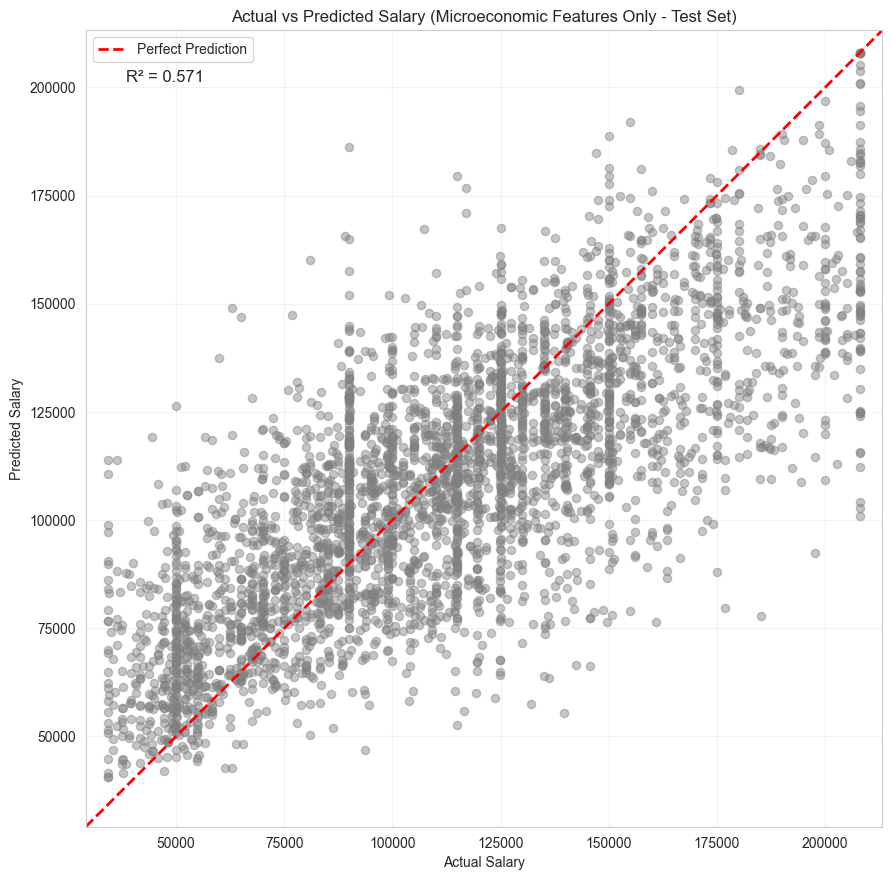

In [50]:
# ============================================================
# ACTUAL vs PREDICTED SCATTER PLOT (MICRO ONLY - TEST SET)
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

# ------------------------------------------------------------
# Use MICRO-ONLY tuned model + features
# ------------------------------------------------------------

test_pred_log = best_xgb.predict(X_test_F)

# Convert from log scale to actual salary scale
test_pred = np.expm1(test_pred_log)
test_actual = np.expm1(y_test.values)

# Convert to numpy arrays
actual_salary = np.array(test_actual)
pred_salary   = np.array(test_pred)

# ------------------------------------------------------------
# Remove invalid values
# ------------------------------------------------------------

mask = np.isfinite(actual_salary) & np.isfinite(pred_salary)

actual_salary = actual_salary[mask]
pred_salary   = pred_salary[mask]

# ------------------------------------------------------------
# Optional clipping for cleaner visualization only
# ------------------------------------------------------------

upper = np.percentile(
    np.concatenate([actual_salary, pred_salary]),
    99
)

actual_plot = np.clip(actual_salary, 0, upper)
pred_plot   = np.clip(pred_salary, 0, upper)

# ------------------------------------------------------------
# Axis range
# ------------------------------------------------------------

min_val = min(actual_plot.min(), pred_plot.min())
max_val = max(actual_plot.max(), pred_plot.max())

pad = (max_val - min_val) * 0.03

axis_min = min_val - pad
axis_max = max_val + pad

# ------------------------------------------------------------
# Compute TRUE Test R² (unclipped values)
# ------------------------------------------------------------

r2 = r2_score(actual_salary, pred_salary)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(9, 9))

plt.scatter(
    actual_plot,
    pred_plot,
    alpha=0.45,
    s=35,
    color="gray"
)

# Perfect prediction line
plt.plot(
    [axis_min, axis_max],
    [axis_min, axis_max],
    linestyle="--",
    linewidth=2,
    color="red",
    label="Perfect Prediction"
)

plt.xlim(axis_min, axis_max)
plt.ylim(axis_min, axis_max)

# fixed y-ticks
y_ticks = np.arange(50000, 200001, 25000)
plt.yticks(y_ticks)

plt.gca().set_aspect("equal", adjustable="box")

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary (Microeconomic Features Only - Test Set)")

plt.text(
    0.05,
    0.95,
    f"R² = {r2:.3f}",
    transform=plt.gca().transAxes,
    verticalalignment="top",
    fontsize=12
)

plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

# Prediction Interval in Current XGBoost Salary Prediction

In [51]:
# ============================================================
# 95% PREDICTION INTERVALS
# RUN THIS AFTER TUNING CODE ABOVE
#
# Uses:
# - best_xgb
# - X_val_F
# - X_test_F
# - y_val
# - y_test
# - test_idx
# - df
#
# IMPORTANT:
# Model predicts salary_log
# Convert back using expm1()
# ============================================================

# ============================================================
# STEP 1: VALIDATION PREDICTIONS (CALIBRATION SET)
# ============================================================

val_pred_log = best_xgb.predict(X_val_F)

val_actual = np.expm1(y_val.values)
val_pred   = np.expm1(val_pred_log)

# absolute residuals in real salary space
val_abs_error = np.abs(val_actual - val_pred)

# ============================================================
# STEP 2: CONFORMAL ERROR QUANTILE
# ============================================================

alpha = 0.05   # 95% interval

q_hat = np.quantile(val_abs_error, 1 - alpha)

print("95% Error Quantile:", round(q_hat,2))

# ============================================================
# STEP 3: TEST SET PREDICTIONS
# ============================================================

test_pred_log = best_xgb.predict(X_test_F)

test_actual = np.expm1(y_test.values)
test_pred   = np.expm1(test_pred_log)

# ============================================================
# STEP 4: BUILD INTERVALS
# ============================================================

lower = test_pred - q_hat
upper = test_pred + q_hat

lower = np.maximum(lower, 0)

# ============================================================
# STEP 5: BUILD RESULTS DATAFRAME
# ============================================================

pi_results = df.loc[test_idx].copy()

pi_results["Actual_Salary"] = test_actual
pi_results["Predicted_Salary"] = test_pred
pi_results["PI_Lower_95"] = lower
pi_results["PI_Upper_95"] = upper

# Was true salary inside interval?
pi_results["Covered"] = (
    (pi_results["Actual_Salary"] >= pi_results["PI_Lower_95"]) &
    (pi_results["Actual_Salary"] <= pi_results["PI_Upper_95"])
).astype(int)

pi_results["Interval_Width"] = (
    pi_results["PI_Upper_95"] - pi_results["PI_Lower_95"]
)

# ============================================================
# STEP 6: SUMMARY
# ============================================================

coverage = pi_results["Covered"].mean()
avg_width = pi_results["Interval_Width"].mean()

summary = pd.DataFrame([{
    "Confidence_Level": "95%",
    "Coverage_Rate": coverage,
    "Average_Interval_Width": avg_width,
    "Median_Interval_Width": pi_results["Interval_Width"].median()
}])

display(summary)

# ============================================================
# STEP 7: SAMPLE OUTPUT
# ============================================================

display(
    pi_results[
        [
            "job_title_short",
            "job_country",
            "Actual_Salary",
            "Predicted_Salary",
            "PI_Lower_95",
            "PI_Upper_95",
            "Covered"
        ]
    ].head(20)
)

# ============================================================
# STEP 8: COVERAGE BY JOB TITLE
# ============================================================

coverage_title = (
    pi_results.groupby("job_title_short")["Covered"]
    .mean()
    .sort_values()
)

display(coverage_title)

# ============================================================
# STEP 9: COVERAGE BY COUNTRY
# ============================================================

coverage_country = (
    pi_results.groupby("job_country")["Covered"]
    .mean()
)

display(coverage_country)

95% Error Quantile: 57750.38


,Confidence_Level,Coverage_Rate,Average_Interval_Width,Median_Interval_Width
0,95%,0.950794,115263.332764,115500.754687


,job_title_short,job_country,Actual_Salary,Predicted_Salary,PI_Lower_95,PI_Upper_95,Covered
312,Senior Data Engineer,United States,155000.000000,145669.421875,87919.044531,203419.799219,1
3274,Senior Data Engineer,United States,160000.000000,123613.148438,65862.771094,181363.525781,1
1915,Data Analyst,United States,37398.399048,50102.730469,0.000000,107853.107812,1
11860,Data Engineer,United States,112500.000000,111071.140625,53320.763281,168821.517969,1
5332,Data Analyst,United States,105000.000000,71571.882812,13821.505469,129322.260156,1
14825,Data Analyst,United States,69680.000000,98701.593750,40951.216406,156451.971094,1
536,Data Scientist,United States,102500.000000,112295.250000,54544.872656,170045.627344,1
1103,Data Analyst,United States,161200.000000,94032.242188,36281.864844,151782.619531,0
2767,Data Scientist,United States,184080.000000,138564.578125,80814.200781,196314.955469,1
8679,Data Analyst,United States,109200.000000,106812.367188,49061.989844,164562.744531,1


job_title_short
Machine Learning Engineer    0.764706
Senior Data Scientist        0.934783
Data Scientist               0.940223
Senior Data Analyst          0.947674
Senior Data Engineer         0.950673
Data Engineer                0.951220
Data Analyst                 0.963950
Software Engineer            0.970588
Business Analyst             0.976378
Name: Covered, dtype: float64

job_country
Canada           0.927711
United States    0.951312
Name: Covered, dtype: float64

In [52]:
# ============================================================
# STANDARD MODEL PERFORMANCE METRICS
# ============================================================

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

perf = pd.DataFrame([{
    "R2": r2_score(test_actual, test_pred),
    "MAE": mean_absolute_error(test_actual, test_pred),
    "RMSE": np.sqrt(mean_squared_error(test_actual, test_pred)),
    "Coverage_95PI": coverage,
    "Avg_PI_Width": avg_width
}])

display(perf)

,R2,MAE,RMSE,Coverage_95PI,Avg_PI_Width
0,0.570908,21092.806247,27607.671018,0.950794,115263.332764


# Explainability (Best Model)

Uses the tuned version of the `XGB + SBERT + TF-IDF + Micro (No Salary)` model.

In [53]:
# SHAP
explainer = shap.TreeExplainer(best_xgb)

In [54]:
all_skills = sorted({
    skill
    for skills in df["skills_list"]
    if isinstance(skills, list)
    for skill in skills
})

print("Number of unique skills:", len(all_skills))

Number of unique skills: 214


In [55]:
eval_n = 100

np.random.seed(42)
sample_idx = np.random.choice(X_test_F.shape[0], size=eval_n, replace=False)

X_eval = X_test_F[sample_idx].toarray()

shap_values = explainer.shap_values(X_eval)
shap_interaction_values = explainer.shap_interaction_values(X_eval)

In [56]:
# ============================================================
# DEFINE FEATURES + FILTER SKILLS (FIXED ORDER)
# ============================================================

# Feature names
structured_names = list(X_train.columns)
sbert_names = [f"SBERT_{i}" for i in range(emb_train.shape[1])]
tfidf_names = list(tfidf.get_feature_names_out())

feature_names = structured_names + sbert_names + tfidf_names

# Convert to DataFrames
shap_df = pd.DataFrame(shap_values, columns=feature_names)
X_eval_df = pd.DataFrame(X_eval, columns=feature_names)

# Build skill set
skill_set = set(all_skills)

# ============================================================
# COLI FEATURE IMPORTANCE (SHAP)
# ============================================================

coli_in_features = [
    c for c in coli_cols + ["coli_matched"]
    if c in feature_names
]

coli_shap = shap_df[coli_in_features].abs().mean().sort_values(ascending=False)

print("COLI Feature Importance:")
display(coli_shap)

# Initial skill columns (exact match)
skill_cols = [
    col for col in feature_names
    if col.lower() in skill_set
]

print("Skills BEFORE filter:", len(skill_cols))

# Create dense test data (needed for filtering)
X_test_dense = pd.DataFrame(X_test_F.toarray(), columns=feature_names)

# ============================================================
# FILTER SKILLS (importance + test presence)
# ============================================================

importances = best_xgb.feature_importances_

MIN_IMPORTANCE = 1e-4
MIN_TEST_PRESENCE = 5

filtered_skill_cols = []

for col in skill_cols:
    feat_idx = feature_names.index(col)
    importance = importances[feat_idx]
    test_presence = (X_test_dense[col] == 1).sum()
    
    if importance >= MIN_IMPORTANCE and test_presence >= MIN_TEST_PRESENCE:
        filtered_skill_cols.append(col)

# overwrite ONCE
skill_cols = filtered_skill_cols

print("Skills AFTER filter:", len(skill_cols))
print("Sample:", skill_cols[:10])

# Final indices + subsets
skill_indices = [feature_names.index(col) for col in skill_cols]

X_eval_skills = X_eval_df[skill_cols]
shap_skills = shap_df[skill_cols]

COLI Feature Importance:


coli_groceries     0.006923
coli_transport     0.004145
coli_housing       0.004068
coli_restaurant    0.002818
coli_matched       0.002166
coli_utilities     0.001543
dtype: float32

Skills BEFORE filter: 175
Skills AFTER filter: 12
Sample: ['aws', 'excel', 'flow', 'oracle', 'python', 'sap', 'sas', 'sharepoint', 'spreadsheet', 'sql']


This code checks if the top-10 SHAP skills stay consistent across different random samples and sample sizes:
- Was used to determine the right value of `n_eval`s to use
- Shows that the results are stable and not just due to chance—makes the findings more reliable for thesis defense

In [57]:
# ============================================================
# SHAP SAMPLE SIZE STABILITY TEST (MULTI-SEED)
# ============================================================

sample_sizes = [30, 100, 200, 300, 500]
seeds = [42, 123, 7, 2024, 99]

results = {n: [] for n in sample_sizes}

for n in sample_sizes:
    for seed in seeds:
        rng = np.random.RandomState(seed)
        idx = rng.choice(X_test_F.shape[0], size=n, replace=False)
        X_eval_tmp = X_test_F[idx].toarray()
        
        shap_vals_tmp = explainer.shap_values(X_eval_tmp)
        shap_df_tmp = pd.DataFrame(shap_vals_tmp, columns=feature_names)
        
        shap_skills_tmp = shap_df_tmp[skill_cols]
        importance_tmp = shap_skills_tmp.abs().mean().sort_values(ascending=False)
        
        # store top 10 skills for this run
        results[n].append(importance_tmp.head(10).index.tolist())

**Jaccard Stability**  
- Checks if the top-10 SHAP skills stay the same across different random samples at the same sample size ($n$).

How it works
- Run SHAP multiple times (different seeds) → get top-10 skill lists  
- Compare every pair using:

$$
J(A, B) = \frac{|A \cap B|}{|A \cup B|}
$$

In [58]:
# ============================================================
# JACCARD STABILITY (WITHIN SAME n)
# ============================================================

from itertools import combinations
import numpy as np

def jaccard(a, b):
    return len(set(a) & set(b)) / len(set(a) | set(b))

print("\nWithin-n Stability (Jaccard):")

for n in sample_sizes:
    pairs = list(combinations(results[n], 2))
    overlaps = [jaccard(a, b) for a, b in pairs]
    
    print(f"n={n}: mean={np.mean(overlaps):.3f} ± {np.std(overlaps):.3f}")


Within-n Stability (Jaccard):
n=30: mean=0.873 ± 0.083
n=100: mean=0.873 ± 0.083
n=200: mean=0.873 ± 0.083
n=300: mean=0.891 ± 0.089
n=500: mean=0.927 ± 0.089


## Global SHAP

C:\Users\Raymond\AppData\Local\Temp\ipykernel_23548\1237661479.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


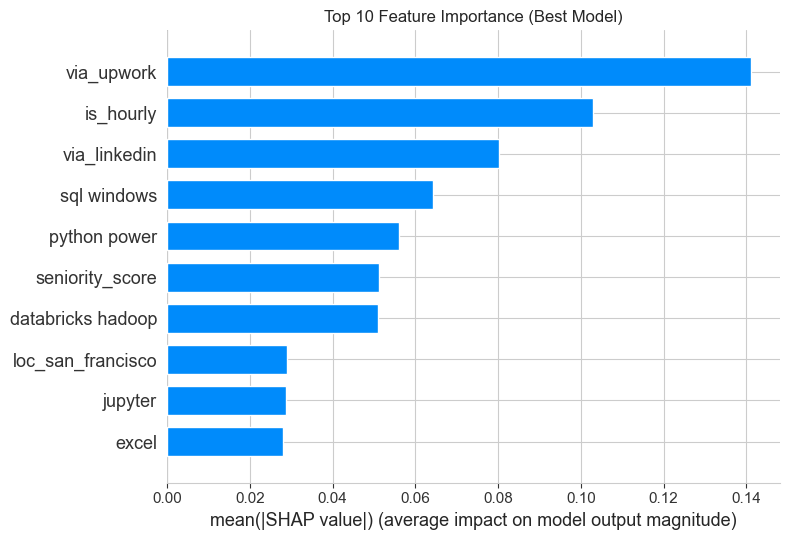

In [59]:
plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values,
    X_eval,
    feature_names=feature_names,
    plot_type="bar",
    max_display=10,
    show=False
)

plt.title("Top 10 Feature Importance (Best Model)")
plt.tight_layout()
plt.show()

This cell computes the importance of each skill using SHAP values. It calculates the average absolute SHAP value to measure how much each skill impacts salary predictions, and the mean SHAP value to show whether the effect is positive or negative. The results are combined into a dataframe, sorted by importance, and the top 20 most influential skills are displayed.

In [60]:
skill_impact_abs = shap_skills.abs().mean()
skill_impact_signed = shap_skills.mean()

skill_impact_df = pd.DataFrame({
    "Skill": skill_impact_abs.index,
    "Importance": skill_impact_abs.values,
    "Direction": skill_impact_signed.values
}).sort_values("Importance", ascending=False)

display(skill_impact_df.head(20))

,Skill,Importance,Direction
1,excel,0.027884,0.000796
3,oracle,0.005010,-0.003231
9,sql,0.004785,0.004357
4,python,0.004572,0.002621
8,spreadsheet,0.004465,-0.004465
11,word,0.003234,-0.002468
2,flow,0.002683,-0.002634
0,aws,0.002248,0.000694
5,sap,0.002030,0.000967
6,sas,0.001931,-0.001762


In [61]:
# ============================================================
# SELECT TOP SKILLS FOR INTERACTION ANALYSIS
# ============================================================

TOP_N = 15

top_skills = skill_impact_df.head(TOP_N)["Skill"].tolist()

print("Top skills used for interaction filtering:")
print(top_skills)

Top skills used for interaction filtering:
['excel', 'oracle', 'sql', 'python', 'spreadsheet', 'word', 'flow', 'aws', 'sap', 'sas', 'tableau', 'sharepoint']


In [62]:
interaction_matrix = shap_interaction_values[:, skill_indices, :][:, :, skill_indices]

mean_interactions = interaction_matrix.mean(axis=0)

pairs = []
for i in range(len(skill_cols)):
    for j in range(i+1, len(skill_cols)):
        pairs.append({
            "skill_1": skill_cols[i],
            "skill_2": skill_cols[j],
            "interaction": mean_interactions[i, j]
        })

interaction_pairs_df = pd.DataFrame(pairs)

top_pairs = interaction_pairs_df.reindex(
    interaction_pairs_df["interaction"].abs().sort_values(ascending=False).index
)

# ============================================================
# FILTER INTERACTIONS TO TOP SKILLS
# ============================================================

filtered_pairs = top_pairs[
    top_pairs["skill_1"].isin(top_skills) &
    top_pairs["skill_2"].isin(top_skills)
].copy()

# remove duplicates (same skill twice)
filtered_pairs = filtered_pairs[
    filtered_pairs["skill_1"] != filtered_pairs["skill_2"]
]

# select final pairs
NUM_PAIRS = 5
selected_pairs = filtered_pairs.head(NUM_PAIRS)

print("Selected pairs:")
display(selected_pairs)

display(top_pairs.head(10))

Selected pairs:


,skill_1,skill_2,interaction
13,excel,python,-0.000224
46,sap,sharepoint,-0.000219
42,python,sql,-0.000208
19,excel,tableau,0.000145
18,excel,sql,0.000143


,skill_1,skill_2,interaction
13,excel,python,-0.000224
46,sap,sharepoint,-0.000219
42,python,sql,-0.000208
19,excel,tableau,0.000145
18,excel,sql,0.000143
30,oracle,python,-0.000142
20,excel,word,-0.000118
8,aws,sql,0.000107
44,python,word,0.000101
53,sas,sql,0.000087


In [63]:
for _, pair in selected_pairs.iterrows():
    s1, s2 = pair["skill_1"], pair["skill_2"]
    p1 = (X_test_dense[s1] == 1).sum()
    p2 = (X_test_dense[s2] == 1).sum()
    print(f"{s1} ({p1}) × {s2} ({p2})")

excel (79) × python (47)
sap (9) × sharepoint (5)
python (47) × sql (66)
excel (79) × tableau (12)
excel (79) × sql (66)


This cell verifies the selected skill pairs used for interaction analysis. It displays the pairs and counts how often each skill appears in the test set (`X_test_dense`). This ensures the skills are present enough in the data to make the interaction results reliable.

In [64]:
print("Selected pairs verification:")
display(selected_pairs)

for _, pair in selected_pairs.iterrows():
    s1, s2 = pair["skill_1"], pair["skill_2"]
    p1 = (X_test_dense[s1] == 1).sum()
    p2 = (X_test_dense[s2] == 1).sum()
    print(f"{s1} ({p1}) × {s2} ({p2})")

Selected pairs verification:


,skill_1,skill_2,interaction
13,excel,python,-0.000224
46,sap,sharepoint,-0.000219
42,python,sql,-0.000208
19,excel,tableau,0.000145
18,excel,sql,0.000143


excel (79) × python (47)
sap (9) × sharepoint (5)
python (47) × sql (66)
excel (79) × tableau (12)
excel (79) × sql (66)


This cell plots the top 12 most important features in the model using SHAP values. It shows the average impact each feature has on salary predictions based on the sampled test data (`X_eval`). Features with higher values have a stronger influence on the model’s output, giving a clear global ranking of what drives predictions.

C:\Users\Raymond\AppData\Local\Temp\ipykernel_23548\3600705602.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


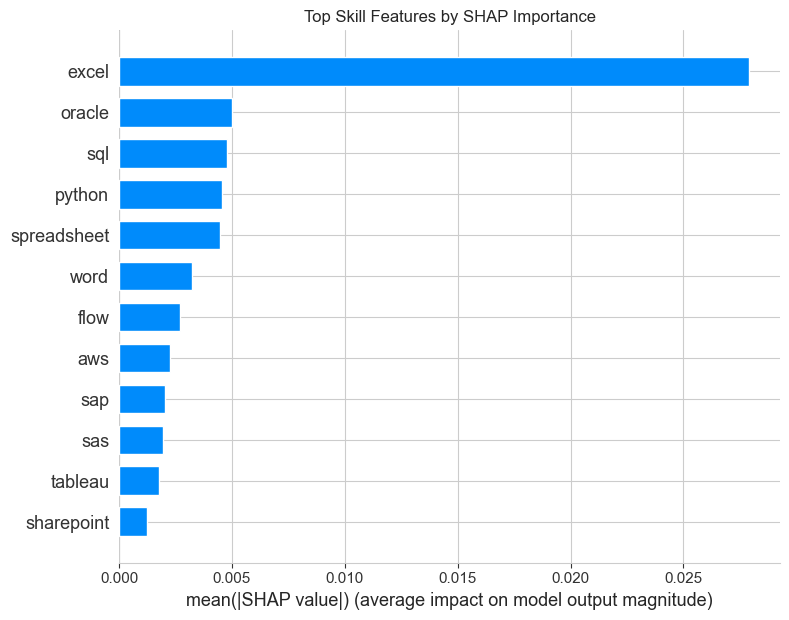

In [65]:
plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_skills.values,
    X_eval_skills,
    feature_names=skill_cols,
    plot_type="bar",
    max_display=12,
    show=False
)

plt.title("Top Skill Features by SHAP Importance")
plt.tight_layout()

# save image
plt.savefig("Top Skill Features Affecting Salary.png", dpi=300, bbox_inches="tight")

plt.show()

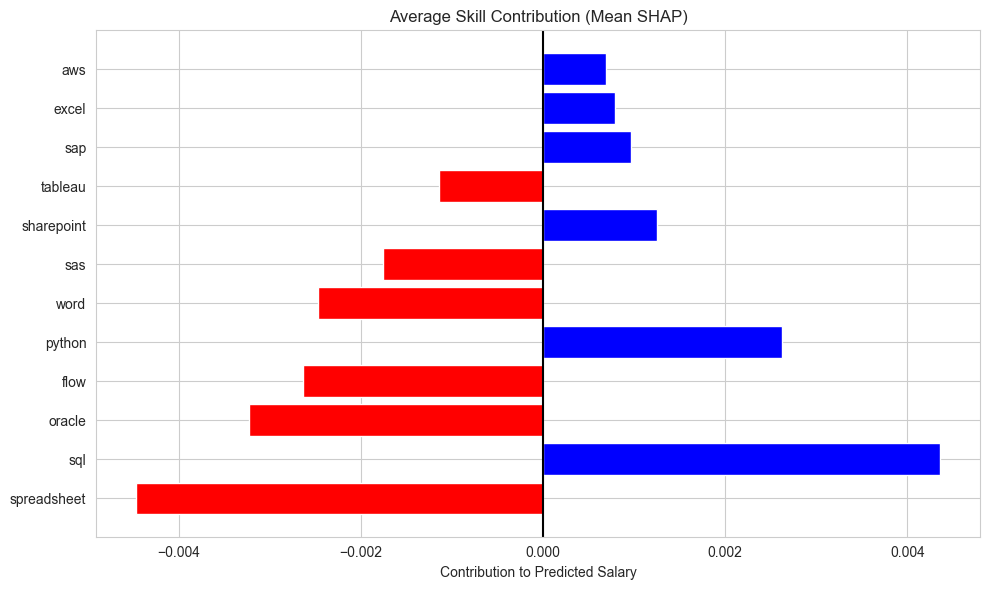

In [66]:
import numpy as np
import matplotlib.pyplot as plt

# Compute mean SHAP 
mean_shap = shap_skills.mean()

# Top 12 by importance
top_features = mean_shap.abs().sort_values(ascending=False).head(12).index
values = mean_shap[top_features]

plt.figure(figsize=(10,6))

colors = ["blue" if v > 0 else "red" for v in values]

plt.barh(values.index, values.values, color=colors)
plt.axvline(0, color='black')

plt.title("Average Skill Contribution (Mean SHAP)")
plt.xlabel("Contribution to Predicted Salary")

plt.tight_layout()
plt.savefig("mean_shap_bar.png", dpi=300, bbox_inches="tight")
plt.show()

# # -----------------------------
# # 2. OPTIONAL: Waterfall-style (visual only)
# # -----------------------------
# cumulative = np.cumsum(values)

# plt.figure(figsize=(10,6))

# for i, (feat, val) in enumerate(values.items()):
#     color = "red" if val > 0 else "blue"
#     plt.barh(feat, val, left=cumulative[i] - val, color=color)

# plt.axvline(0, color='black')

# plt.title("Average Skill Contribution (Waterfall Style - Visual Only)")
# plt.xlabel("Contribution to Predicted Salary")

# plt.tight_layout()
# plt.savefig("global_waterfall_style.png", dpi=300, bbox_inches="tight")
# plt.show()

C:\Users\Raymond\AppData\Local\Temp\ipykernel_23548\1755245094.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


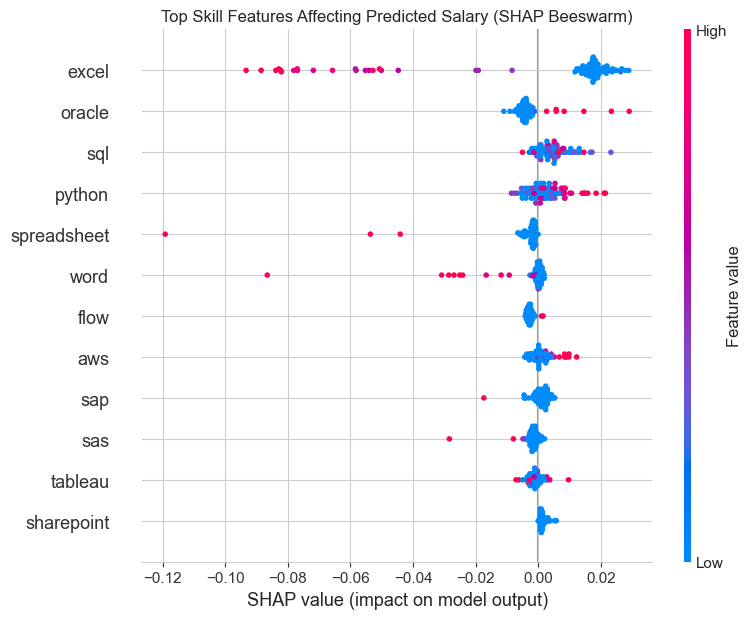

In [67]:
import matplotlib.pyplot as plt
import shap

plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_skills.values,
    X_eval_skills,
    feature_names=skill_cols,
    max_display=12,
    show=False
)

plt.title("Top Skill Features Affecting Predicted Salary (SHAP Beeswarm)")
plt.tight_layout()

plt.savefig("Top Skill Features Beeswarm.png", dpi=300, bbox_inches="tight")

plt.show()

Waterfall plot. Ignore this because it only uses it on one sample

In [68]:
# import shap

# # pick ONE sample (important)
# i = 0  

# shap.waterfall_plot(
#     shap.Explanation(
#         values=shap_values[i],
#         base_values=explainer.expected_value,
#         data=X_eval[i],
#         feature_names=feature_names
#     )
# )

## Skill Interactions

In [69]:
def get_skill_indices(skill, feature_names):
    skill_lower = skill.lower().strip()
    idx = [i for i, f in enumerate(feature_names) if f.lower() == skill_lower]
    if not idx:
        pattern = r"\b" + re.escape(skill_lower) + r"\b"
        idx = [i for i, f in enumerate(feature_names) if re.search(pattern, f.lower())]
    return idx


Analyzing: excel × python
Mean interaction: -0.00022358405


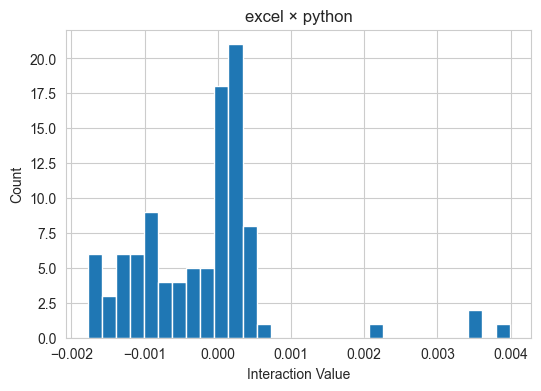


Analyzing: sap × sharepoint
Mean interaction: -0.00021949988


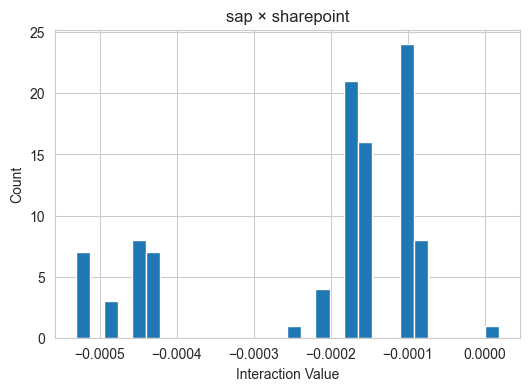


Analyzing: python × sql
Mean interaction: -0.00020825402


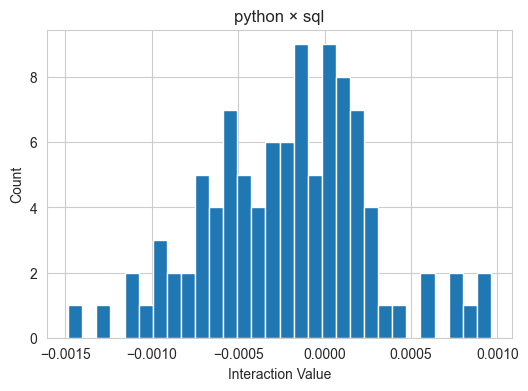


Analyzing: excel × tableau
Mean interaction: 0.00014466299


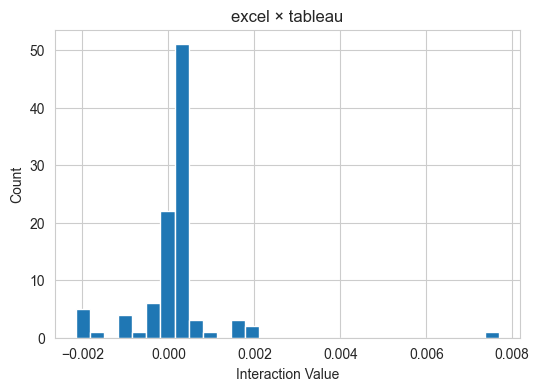


Analyzing: excel × sql
Mean interaction: 0.00014262006


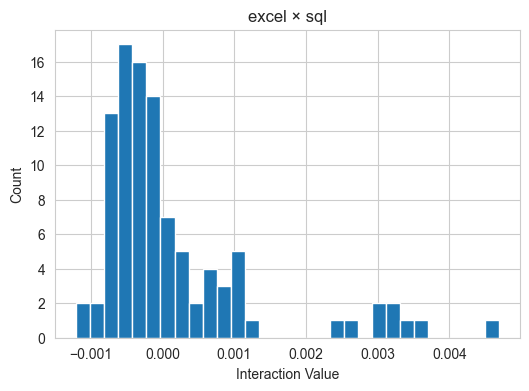

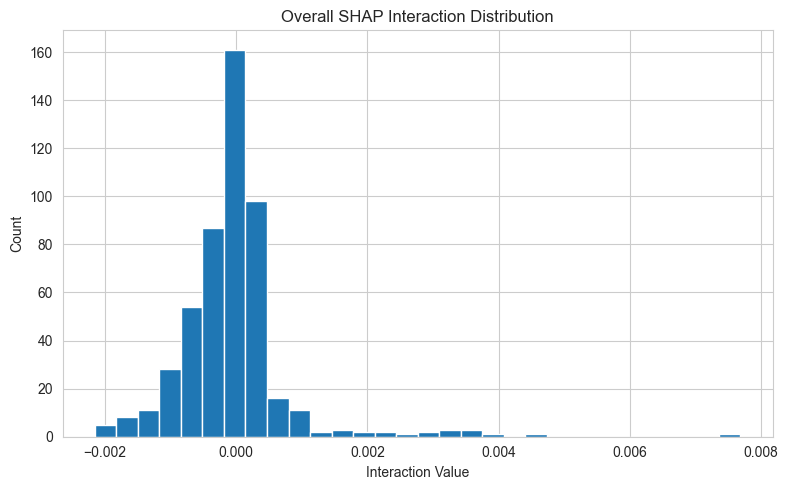

In [70]:
all_interaction_vals = []

for _, pair in selected_pairs.iterrows():

    skill_1 = pair["skill_1"]
    skill_2 = pair["skill_2"]

    print("\n======================")
    print("Analyzing:", skill_1, "×", skill_2)

    skill_1_idx = get_skill_indices(skill_1, feature_names)
    skill_2_idx = get_skill_indices(skill_2, feature_names)

    # Skip if not found
    if len(skill_1_idx) == 0 or len(skill_2_idx) == 0:
        print("Skipping (not found)")
        continue

    # Compute interaction
    interaction_vals = shap_interaction_values[:, skill_1_idx, :][:, :, skill_2_idx].mean(axis=(1,2))

    print("Mean interaction:", interaction_vals.mean())

    all_interaction_vals.extend(interaction_vals)

    # Plot per pair
    plt.figure(figsize=(6,4))
    plt.hist(interaction_vals, bins=30)
    plt.title(f"{skill_1} × {skill_2}")
    plt.xlabel("Interaction Value")
    plt.ylabel("Count")
    plt.show()


# GLOBAL DISTRIBUTION
plt.figure(figsize=(8,5))
plt.hist(all_interaction_vals, bins=30)

plt.title("Overall SHAP Interaction Distribution")
plt.xlabel("Interaction Value")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

## EDA (before Counterfactuals)

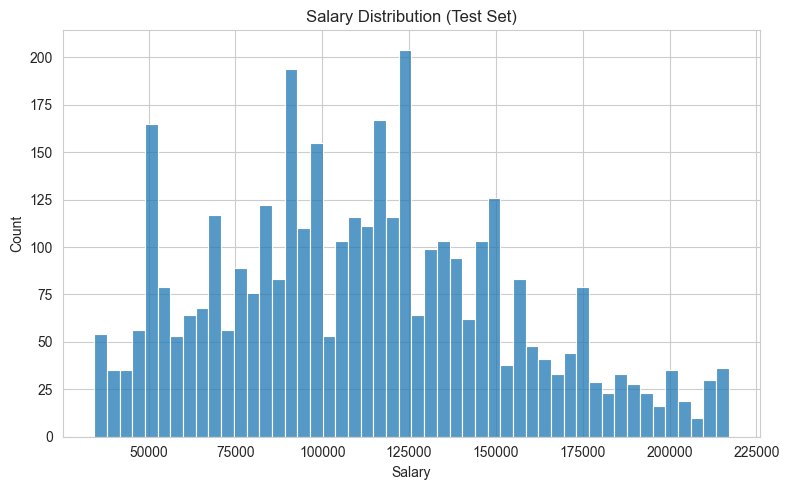

In [71]:
plt.figure(figsize=(8,5))

sns.histplot(np.expm1(y_test.values), bins=50)

plt.title("Salary Distribution (Test Set)")
plt.xlabel("Salary")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Just checked the salary distribution again because my plan was that we were going to select the entries for the counterfactuals based off salary brackets so that there's more representation. It describes how the market values skills across different job levels. 

## Counterfactuals

In [72]:
# ============================================================
# COUNTERFACTUAL HELPERS
# ============================================================

def get_skill_columns(skill):
    skill_lower = skill.lower().strip()
    matches = [c for c in feature_names if c.lower() == skill_lower]
    if not matches:
        pattern = r"\b" + re.escape(skill_lower) + r"\b"
        matches = [c for c in feature_names if re.search(pattern, c.lower())]
    return matches

def add_skill(row, skill):
    row_new = row.copy()
    cols = get_skill_columns(skill)
    for c in cols:
        if row_new[c] == 0:
            row_new[c] = 1
    return row_new

**Counterfactual Sample Size Determination**

This section determines how many samples (`n`) are needed for reliable counterfactual analysis. It selects the most important skill pair and evaluates their interaction effect across different sample sizes, using a stratified approach (low, mid, high salary tiers) to ensure balanced representation. For each sample size, bootstrap resampling is applied to compute a 95% confidence interval for the interaction effect.

The key idea is that as sample size increases, the confidence interval becomes narrower, meaning the estimate is more stable and precise. By plotting confidence interval width against total sample size, we can visually identify where adding more samples gives diminishing returns. This justifies the chosen `n` for counterfactual analysis as a balance between statistical reliability and computational efficiency.

Calibrating sample size using: excel x python


,per_tier,total_n,mean_interaction,ci_low,ci_high,ci_width,relative_width
0,10,30,300.000000,87.370880,546.379211,459.008331,1.530028
1,25,75,286.864471,162.800400,434.009827,271.209412,0.945427
2,50,150,369.447510,268.126373,481.831665,213.705292,0.578446
3,100,300,320.337646,248.703918,392.111511,143.407593,0.447676
4,200,600,314.691315,265.991943,366.379242,100.387299,0.319002


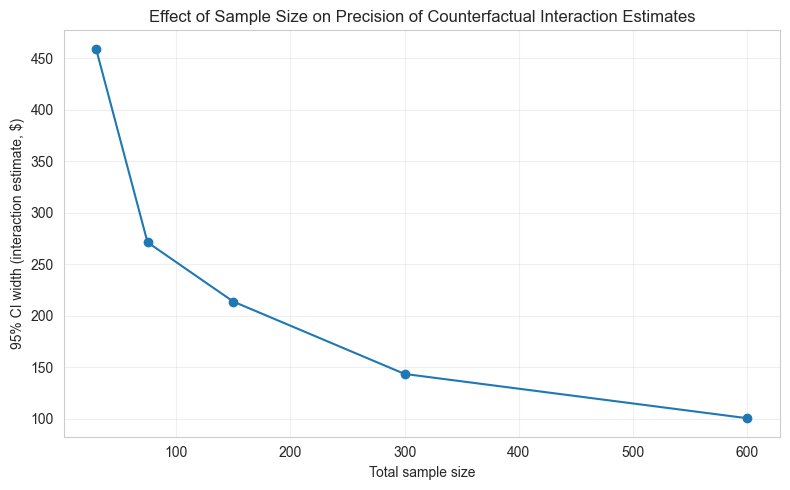

In [73]:
# ============================================================
# COUNTERFACTUAL SAMPLE SIZE DETERMINATION
# ============================================================

from scipy import stats

# pick the most important pair to calibrate on
test_skill_1 = selected_pairs.iloc[0]["skill_1"]
test_skill_2 = selected_pairs.iloc[0]["skill_2"]

print(f"Calibrating sample size using: {test_skill_1} x {test_skill_2}")

# build tier-stratified index pool from full test set
test_df_full = pd.DataFrame({"salary": np.expm1(y_test.values)})
test_df_full["bin"] = pd.qcut(test_df_full["salary"], q=3, labels=["low", "mid", "high"])

def sample_stratified(per_tier, seed):
    idx = []
    for b in ["low", "mid", "high"]:
        pool = test_df_full[test_df_full["bin"] == b].index
        chosen = np.random.RandomState(seed).choice(pool, size=per_tier, replace=False)
        idx.extend(chosen)
    return idx

def compute_interaction_for_sample(indices, s1, s2):
    gains_s1, gains_s2, interactions = [], [], []
    for i in indices:
        row = X_test_dense.iloc[i].copy()
        base = np.expm1(best_xgb.predict(row.values.reshape(1, -1))[0])
        
        s1_pred = np.expm1(best_xgb.predict(
            add_skill(row, s1).values.reshape(1, -1))[0])
        s2_pred = np.expm1(best_xgb.predict(
            add_skill(row, s2).values.reshape(1, -1))[0])
        
        both_row = add_skill(add_skill(row, s1), s2)
        both_pred = np.expm1(best_xgb.predict(both_row.values.reshape(1, -1))[0])
        
        g1 = s1_pred - base
        g2 = s2_pred - base
        gains_s1.append(g1)
        gains_s2.append(g2)
        interactions.append((both_pred - base) - (g1 + g2))
    return np.array(gains_s1), np.array(gains_s2), np.array(interactions)

# sweep sample sizes per tier
per_tier_sizes = [10, 25, 50, 100, 200]
n_bootstrap = 1000
results = []

for per_tier in per_tier_sizes:
    # limit per_tier to available tier size
    max_available = test_df_full["bin"].value_counts().min()
    if per_tier > max_available:
        print(f"Skipping {per_tier} (only {max_available} available per tier)")
        continue
    
    indices = sample_stratified(per_tier, seed=42)
    g1, g2, inter = compute_interaction_for_sample(indices, test_skill_1, test_skill_2)
    
    # bootstrap 95% CI for each quantity
    def boot_ci(arr):
        means = [np.mean(np.random.choice(arr, size=len(arr), replace=True))
                 for _ in range(n_bootstrap)]
        return np.percentile(means, 2.5), np.percentile(means, 97.5)
    
    inter_lo, inter_hi = boot_ci(inter)
    
    results.append({
        "per_tier": per_tier,
        "total_n": len(indices),
        "mean_interaction": inter.mean(),
        "ci_low": inter_lo,
        "ci_high": inter_hi,
        "ci_width": inter_hi - inter_lo,
        "relative_width": (inter_hi - inter_lo) / abs(inter.mean()) if inter.mean() != 0 else np.nan
    })

sample_size_df = pd.DataFrame(results)
display(sample_size_df)

# plot CI width vs n
plt.figure(figsize=(8, 5))
plt.plot(sample_size_df["total_n"], sample_size_df["ci_width"], marker="o")
plt.xlabel("Total sample size")
plt.ylabel("95% CI width (interaction estimate, $)")
plt.title("Effect of Sample Size on Precision of Counterfactual Interaction Estimates")
plt.grid(alpha=0.3)
plt.tight_layout()

# save image
plt.savefig("counterfactual_sample_size_vs_precision.png", dpi=300, bbox_inches="tight")

plt.show()

## Counterfactuals One Sample (for experimenting purposes only, do not include in paper)

This is an illustrative example of a single job profile. Final conclusions are based on aggregated results.

In [74]:
# pick ONE sample
row = X_test_dense.iloc[0].copy()

# pick ONE pair (just for demo)
skill_1 = selected_pairs.iloc[0]["skill_1"]
skill_2 = selected_pairs.iloc[0]["skill_2"]

print("Using skills:", skill_1, "and", skill_2)

# base prediction
base_pred_log = best_xgb.predict(row.values.reshape(1, -1))[0]
base_salary = np.expm1(base_pred_log)

print("Base salary:", base_salary)

# skill 1
row_s1 = add_skill(row, skill_1)
s1 = np.expm1(best_xgb.predict(row_s1.values.reshape(1,-1))[0])
s1_gain = s1 - base_salary

# skill 2
row_s2 = add_skill(row, skill_2)
s2 = np.expm1(best_xgb.predict(row_s2.values.reshape(1,-1))[0])
s2_gain = s2 - base_salary

# both
row_both = add_skill(row, skill_1)
row_both = add_skill(row_both, skill_2)
both = np.expm1(best_xgb.predict(row_both.values.reshape(1,-1))[0])
both_gain = both - base_salary

# interaction
expected = s1_gain + s2_gain
interaction = both_gain - expected

# print results
print(f"{skill_1} gain:", s1_gain)
print(f"{skill_2} gain:", s2_gain)
print("Both gain:", both_gain)
print("Expected (additive):", expected)
print("Interaction:", interaction)

Using skills: excel and python
Base salary: 84555.46
excel gain: -7050.953
python gain: 0.0
Both gain: -7050.953
Expected (additive): -7050.953
Interaction: 0.0


## Aggregated Results (Final, include this in paper)

In [75]:
test_df = pd.DataFrame({
    "salary": np.expm1(y_test.values)
})

test_df["bin"] = pd.qcut(
    test_df["salary"],
    q=3,
    labels=["low", "mid", "high"]
)

PER_TIER_N = 100  # gives total_n ≈ 300

sample_indices = []

for b in ["low", "mid", "high"]:
    idx = test_df[test_df["bin"] == b].sample(PER_TIER_N, random_state=42).index
    sample_indices.extend(idx)

In [76]:
def boot_ci(arr, n=1000):
    means = [
        np.mean(np.random.choice(arr, size=len(arr), replace=True))
        for _ in range(n)
    ]
    return np.percentile(means, 2.5), np.percentile(means, 97.5)

In [77]:
cf_results = []

for _, pair in selected_pairs.iterrows():

    skill_1 = pair["skill_1"]
    skill_2 = pair["skill_2"]

    print("\n======================")
    print("Skills:", skill_1, "and", skill_2)

    results = []

    for i in sample_indices:
        row = X_test_dense.iloc[i].copy()

        base = np.expm1(best_xgb.predict(row.values.reshape(1,-1))[0])

        # skill 1
        row_s1 = add_skill(row, skill_1)
        s1 = np.expm1(best_xgb.predict(row_s1.values.reshape(1,-1))[0])

        # skill 2
        row_s2 = add_skill(row, skill_2)
        s2 = np.expm1(best_xgb.predict(row_s2.values.reshape(1,-1))[0])

        # both
        row_both = add_skill(row, skill_1)
        row_both = add_skill(row_both, skill_2)
        both = np.expm1(best_xgb.predict(row_both.values.reshape(1,-1))[0])

        skill_1_gain = s1 - base
        skill_2_gain = s2 - base
        both_gain = both - base

        expected = skill_1_gain + skill_2_gain
        interaction = both_gain - expected

        results.append({
            "skill_1_gain": skill_1_gain,
            "skill_2_gain": skill_2_gain,
            "interaction": interaction
        })

    interaction_df = pd.DataFrame(results)

    print("\nSummary:")
    display(interaction_df.describe())

    # -------------------------
    # Tier analysis
    # -------------------------
    interaction_df["tier"] = test_df.loc[sample_indices, "bin"].values

    grouped = interaction_df.groupby("tier", observed=True)[[
        "skill_1_gain",
        "skill_2_gain",
        "interaction"
    ]].mean()

    grouped.columns = [
        f"{skill_1} Gain",
        f"{skill_2} Gain",
        "Interaction"
    ]

    print("\nTier Analysis:")
    display(grouped)

    # -------------------------
    # Summary stats
    # -------------------------
    avg_s1 = interaction_df["skill_1_gain"].mean()
    avg_s2 = interaction_df["skill_2_gain"].mean()
    avg_interaction = interaction_df["interaction"].mean()

    # -------------------------
    # BOOTSTRAP (CORRECT PLACEMENT)
    # -------------------------
    inter_lo, inter_hi = boot_ci(interaction_df["interaction"].values)

    print(f"\nMean interaction: {avg_interaction:.2f} (95% CI: [{inter_lo:.2f}, {inter_hi:.2f}])")

    if inter_lo > 0:
        print("Significantly positive interaction (synergy)")
    elif inter_hi < 0:
        print("Significantly negative interaction (diminishing returns)")
    else:
        print("Interaction not statistically distinguishable from zero")

    # -------------------------
    # Skill effects
    # -------------------------
    print(f"{skill_1} increases predicted salary by approx: {avg_s1:.2f}")
    print(f"{skill_2} increases predicted salary by approx: {avg_s2:.2f}")

    if avg_interaction < 0:
        print("Negative interaction (diminishing returns)")
    else:
        print("Positive interaction (synergy)")

    # -------------------------
    # Store results
    # -------------------------
    cf_results.append({
        "skill_1": skill_1,
        "skill_2": skill_2,
        "avg_s1_gain": avg_s1,
        "avg_s2_gain": avg_s2,
        "avg_interaction": avg_interaction,
        "ci_low": inter_lo,
        "ci_high": inter_hi
    })

# Final table
interaction_summary = pd.DataFrame(cf_results)
display(interaction_summary)


Skills: excel and python

Summary:


,skill_1_gain,skill_2_gain,interaction
count,300.000000,300.000000,300.000000
mean,-5103.030762,432.106934,320.337646
std,3610.628174,1157.302002,637.072449
min,-15726.070312,-2881.750000,-1147.234375
25%,-7486.458984,0.000000,0.000000
50%,-5736.125000,0.000000,0.000000
75%,-2091.050781,490.359375,460.191406
max,0.000000,4867.226562,3237.921875



Tier Analysis:


,excel Gain,python Gain,Interaction
tier,,,
low,-4186.835449,593.804321,419.882904
mid,-5311.174316,435.519135,315.586945
high,-5811.082520,266.997345,225.543121



Mean interaction: 320.34 (95% CI: [256.03, 397.14])
Significantly positive interaction (synergy)
excel increases predicted salary by approx: -5103.03
python increases predicted salary by approx: 432.11
Positive interaction (synergy)

Skills: sap and sharepoint

Summary:


...

,skill_1_gain,skill_2_gain,interaction
count,300.000000,300.000000,300.000000
mean,-5103.030762,-69.876495,59.656551
std,3610.628174,925.793823,705.175598
min,-15726.070312,-3601.195312,-3176.671875
25%,-7486.458984,0.000000,0.000000
50%,-5736.125000,0.000000,0.000000
75%,-2091.050781,0.000000,0.000000
max,0.000000,4996.234375,3259.820312



Tier Analysis:


,excel Gain,sql Gain,Interaction
tier,,,
low,-4186.835449,-171.020279,-98.225822
mid,-5311.174316,17.532265,132.109528
high,-5811.082520,-56.141483,145.085938



Mean interaction: 59.66 (95% CI: [-14.49, 139.31])
Interaction not statistically distinguishable from zero
excel increases predicted salary by approx: -5103.03
sql increases predicted salary by approx: -69.88
Positive interaction (synergy)


,skill_1,skill_2,avg_s1_gain,avg_s2_gain,avg_interaction,ci_low,ci_high
0,excel,python,-5103.030762,432.106934,320.337646,256.034821,397.138336
1,sap,sharepoint,-813.398560,-179.637115,-25.840534,-32.038544,-20.372103
2,python,sql,432.106934,-69.876495,86.243904,54.743511,118.607323
3,excel,tableau,-5103.030762,352.539398,712.002808,595.247437,827.668762
4,excel,sql,-5103.030762,-69.876495,59.656551,-14.492541,139.314972


# Ignore this: extra stuff

In [78]:
print("Selected pairs after filtering:")
display(selected_pairs)

for _, pair in selected_pairs.iterrows():
    s1, s2 = pair["skill_1"], pair["skill_2"]
    p1 = (X_test_dense[s1] == 1).sum()
    p2 = (X_test_dense[s2] == 1).sum()
    print(f"{s1} ({p1}/{len(X_test_dense)}) × {s2} ({p2}/{len(X_test_dense)})")

Selected pairs after filtering:


,skill_1,skill_2,interaction
13,excel,python,-0.000224
46,sap,sharepoint,-0.000219
42,python,sql,-0.000208
19,excel,tableau,0.000145
18,excel,sql,0.000143


excel (79/3780) × python (47/3780)
sap (9/3780) × sharepoint (5/3780)
python (47/3780) × sql (66/3780)
excel (79/3780) × tableau (12/3780)
excel (79/3780) × sql (66/3780)


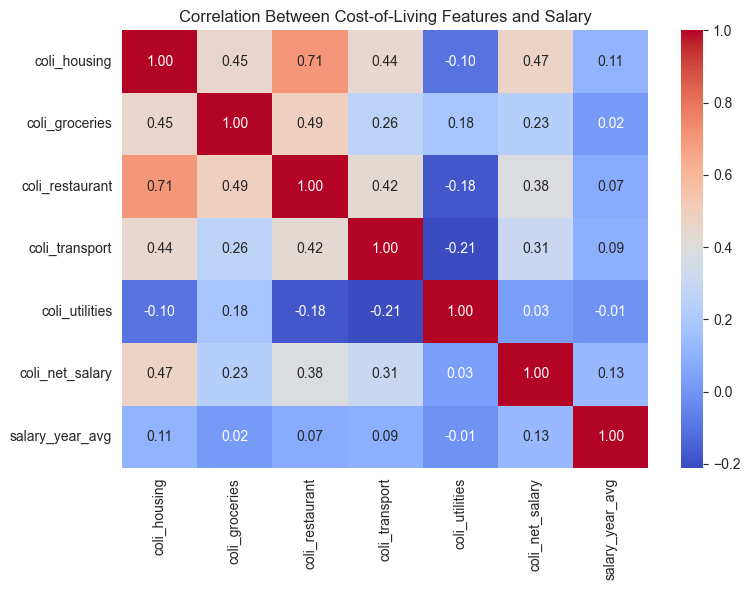

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

coli_features = [
    "coli_housing",
    "coli_groceries",
    "coli_restaurant",
    "coli_transport",
    "coli_utilities",
    "coli_net_salary"
]

corr = df[coli_features + ["salary_year_avg"]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Between Cost-of-Living Features and Salary")
plt.tight_layout()
plt.show()

# Thesis Defense Revisions